# 02 — LightGBM WFO (v6): Conviction-Weighted Leverage + ATH Entry Window

**Extends:** `02_lgbm_omni_0fee_v5.ipynb`

**Key changes vs v5:**
- **Conviction leverage**: signal probability maps to leverage 1×–20× (prob=threshold→1×, prob≥0.90→20×, linear scale).
- **Futures fee model**: fees now apply to BOTH entry and exit on longs (Binance Perpetuals: maker 0.02%, taker 0.05%). Fee cost = fee_rate × leverage.
- **ATH-window start**: Phase 4 backtest begins on the first bar where BTC close ≥ the last OOS close price ("when BTC first hit today's ATH").
- Phase 6 = leverage sensitivity sweep (1× / 5× / 10× / 20× caps).


In [1]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO constants ─────────────────────────────────────────────────────────────
OOS_START  = pd.Timestamp('2024-01-01')
STEP_SIZE  = 720   # bars per WFO step (~1 month at 1h)
EMBARGO    = 12    # embargo bars (12h = label lookahead)
VAL_FRAC   = 0.20  # last fraction of train window for early stopping

LABEL_COL  = 'label'

# ── Backtest defaults ─────────────────────────────────────────────────────────
DEFAULT_THRESHOLD  = 0.55
DEFAULT_ENTRY_ATR  = 0.30
DEFAULT_SL_MULT    = 1.5
DEFAULT_TP_MULT    = 2.0
DEFAULT_MAX_HOLD   = 48
DEFAULT_COOLDOWN   = 4

# ── Leverage model ────────────────────────────────────────────────────────────
DEFAULT_MIN_LEV    = 1.0    # leverage at threshold probability
DEFAULT_MAX_LEV    = 20.0   # leverage at LEV_PROB_HIGH
LEV_PROB_HIGH      = 0.90   # prob at which max leverage is reached
LEV_MAX_LOSS_FRAC  = 0.90   # safety cap: SL can't wipe > 90% of equity

# ── Fee model (Binance Perpetual Futures) — applies to longs in v6 ───────────
# Maker (limit orders): 0.02% per side
# Taker (market orders): 0.05% per side
# Fee cost as % of equity = fee_rate * leverage (fees are on notional)
FUTURES_MAKER_FEE  = 0.0002   # 0.02%
FUTURES_TAKER_FEE  = 0.0005   # 0.05%

# ── Feature selection thresholds ──────────────────────────────────────────────
VAR_THRESHOLD    = 1e-6
CORR_THRESHOLD   = 0.85
TOP_K_MI         = 60
FS_WINDOW_SIZE   = 2160
FS_STEP          = 720
MIN_STABLE_FRAC  = 0.50
TOP_K_PER_WINDOW = 35
PERM_THRESHOLD   = 0.0005

print('Imports OK')


Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found — run from within the repo')

REPO      = _find_repo_root()
RAW_DIR   = REPO / 'data' / 'raw'
FEAT_DIR  = REPO / 'data' / 'features'
ARTS_DIR  = REPO / 'artifacts' / '02_lgbm_omni_0fee_v6'
ARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root : {REPO}')
print(f'Artifacts : {ARTS_DIR}')


Repo root : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
Artifacts : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v6


---
## Phase 1 — Data Loading & Feature Assembly


In [3]:
# ── V1 features (195 model features + backtest-only cols + label) ─────────────
print('Loading V1 features (BTCUSDT_1h_features.parquet)...')
v1_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

# ── V3 features (21 external features) ────────────────────────────────────────
print('Loading V3 features (BTCUSDT_1h_v3_features.parquet)...')
v3_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v3_features.parquet')
v3_df.index = v3_df.index.tz_localize(None) if v3_df.index.tz else v3_df.index

# ── Raw OHLCV (high/low for backtester) ───────────────────────────────────────
print('Loading raw OHLCV (BTCUSDT_1h.parquet)...')
raw_df = pd.read_parquet(
    RAW_DIR / 'BTCUSDT_1h.parquet',
    columns=['open', 'high', 'low', 'close', 'volume'],
)
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index

# ── Feature registry ──────────────────────────────────────────────────────────
with open(FEAT_DIR / 'feature_registry.json') as f:
    registry = json.load(f)
BACKTEST_COLS = registry['backtest_only_cols']  # ['close', 'sma_200', 'atr_14_pct']

print(f'\nV1 shape : {v1_df.shape}  ({v1_df.index.min().date()} → {v1_df.index.max().date()})')
print(f'V3 shape : {v3_df.shape}  ({v3_df.index.min().date()} → {v3_df.index.max().date()})')
print(f'Raw shape: {raw_df.shape}')
print(f'Backtest-only cols: {BACKTEST_COLS}')


Loading V1 features (BTCUSDT_1h_features.parquet)...
Loading V3 features (BTCUSDT_1h_v3_features.parquet)...
Loading raw OHLCV (BTCUSDT_1h.parquet)...

V1 shape : (74366, 199)  (2017-11-15 → 2026-05-16)
V3 shape : (76938, 21)  (2017-08-17 → 2026-05-27)
Raw shape: (76938, 5)
Backtest-only cols: ['close', 'sma_200', 'atr_14_pct']


In [4]:
# Derive column lists
V1_FEATURE_COLS = [c for c in v1_df.columns if c not in BACKTEST_COLS + [LABEL_COL]]
V3_FEATURE_COLS = list(v3_df.columns)

print(f'V1 model features  : {len(V1_FEATURE_COLS)}')
print(f'V3 model features  : {len(V3_FEATURE_COLS)}')
print(f'V3 feature names   : {V3_FEATURE_COLS}')

# Merge: V1 base (has label + backtest_only_cols), add V3, add high/low
merged = v1_df.copy()
for col in v3_df.columns:
    merged[col] = v3_df[col].reindex(merged.index)

# Add high / low for backtester (not used as model features)
merged['high'] = raw_df['high'].reindex(merged.index)
merged['low']  = raw_df['low'].reindex(merged.index)

# Drop rows without label (forward-looking label is NaN at tail)
merged.dropna(subset=[LABEL_COL], inplace=True)

ALL_FEATURE_COLS = V1_FEATURE_COLS + V3_FEATURE_COLS

print(f'\nCombined feature pool : {len(ALL_FEATURE_COLS)} ({len(V1_FEATURE_COLS)} V1 + {len(V3_FEATURE_COLS)} V3)')
print(f'Merged rows           : {len(merged):,}')
print(f'Date range            : {merged.index.min().date()} → {merged.index.max().date()}')
print(f'Label positive rate   : {merged[LABEL_COL].mean():.3f}')

oos_mask = merged.index >= OOS_START
print(f'OOS bars (≥2024-01-01): {oos_mask.sum():,}')


V1 model features  : 195
V3 model features  : 21
V3 feature names   : ['cross_eth_btc_ratio', 'cross_eth_btc_mom_24h', 'cross_eth_btc_mom_72h', 'cross_altcoin_breadth_24h', 'cross_btc_relative_strength', 'cross_alt_correlation_24h', 'mkt_btc_dominance', 'mkt_btc_dominance_chg_7d', 'mkt_eth_dominance', 'mkt_total_mcap_chg_24h', 'mkt_stablecoin_pct', 'sent_fear_greed', 'sent_fear_greed_ma7', 'sent_fear_greed_chg_7d', 'micro_amihud_illiq', 'micro_kyle_lambda', 'micro_roll_spread', 'micro_volume_clock', 'vol_term_structure', 'mom_normalized_24h', 'mom_normalized_72h']

Combined feature pool : 216 (195 V1 + 21 V3)
Merged rows           : 74,366
Date range            : 2017-11-15 → 2026-05-16
Label positive rate   : 0.509
OOS bars (≥2024-01-01): 20,785


---
## Phase 1 — Feature Selection (4-Stage Pipeline)

Selects ~13 features from the 216-feature pool on **pre-OOS training data only** (no leakage).

1. Variance + Spearman correlation filter
2. Mutual Information ranking (top 60)
3. Walk-forward stability (≥50% of windows)
4. Permutation importance pruning (> 0.0005 AUC lift)


In [5]:
# Feature selection uses pre-OOS data only (no data leakage)
train_sel = merged[~oos_mask].copy()
print(f'Feature selection on: {len(train_sel):,} bars')
print(f'  {train_sel.index.min().date()} → {train_sel.index.max().date()}')

# ── STAGE 1: Variance + Spearman correlation filter ───────────────────────────
print('\n' + '='*60)
print('STAGE 1: Variance + Spearman Correlation Filter')
print('='*60)

valid_cols = [
    f for f in ALL_FEATURE_COLS
    if f in train_sel.columns and train_sel[f].notna().sum() > len(train_sel) * 0.50
]
print(f'  Features with >50% non-null: {len(valid_cols)} / {len(ALL_FEATURE_COLS)}')

variances = train_sel[valid_cols].var()
low_var = variances[variances < VAR_THRESHOLD].index.tolist()
candidates = [f for f in valid_cols if f not in low_var]
print(f'  Low-variance removed       : {len(low_var)}')

train_filled = train_sel[candidates].fillna(0)
target_corr  = train_filled.corrwith(train_sel[LABEL_COL], method='spearman').abs()
corr_matrix  = train_filled.corr(method='spearman').abs()

to_drop = set()
for i in range(len(candidates)):
    if candidates[i] in to_drop:
        continue
    for j in range(i + 1, len(candidates)):
        if candidates[j] in to_drop:
            continue
        if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
            keep = (candidates[i]
                    if target_corr.get(candidates[i], 0) >= target_corr.get(candidates[j], 0)
                    else candidates[j])
            drop = candidates[j] if keep == candidates[i] else candidates[i]
            to_drop.add(drop)

stage1 = [f for f in candidates if f not in to_drop]
v3_in_s1 = [f for f in stage1 if f in V3_FEATURE_COLS]
print(f'  Corr-redundant removed     : {len(to_drop)} (ρ > {CORR_THRESHOLD})')
print(f'  Stage 1 survivors          : {len(stage1)}  (V3 in stage1: {len(v3_in_s1)})')

Feature selection on: 53,581 bars
  2017-11-15 → 2023-12-31

STAGE 1: Variance + Spearman Correlation Filter
  Features with >50% non-null: 215 / 216
  Low-variance removed       : 1
  Corr-redundant removed     : 95 (ρ > 0.85)
  Stage 1 survivors          : 119  (V3 in stage1: 14)


In [6]:
# ── STAGE 2: Mutual Information ranking — top 60 ──────────────────────────────
print('STAGE 2: Mutual Information Ranking (top 60)')
print('='*60)

X_s1 = train_sel[stage1].fillna(0).values
y_s1 = train_sel[LABEL_COL].values

t0 = time.time()
mi_scores = mutual_info_classif(X_s1, y_s1, n_neighbors=5, random_state=42)
print(f'  MI computation: {time.time()-t0:.1f}s')

mi_df = pd.DataFrame({
    'feature': stage1,
    'MI':      mi_scores,
    'is_v3':   [f in V3_FEATURE_COLS for f in stage1],
}).sort_values('MI', ascending=False).reset_index(drop=True)

stage2    = mi_df.head(TOP_K_MI)['feature'].tolist()
n_v3_s2   = int(mi_df.head(TOP_K_MI)['is_v3'].sum())
print(f'  Stage 2 survivors: {len(stage2)}  (V3 in top {TOP_K_MI}: {n_v3_s2})')
print('\n  Top 20 features by MI:')
print(mi_df.head(20)[['feature','MI','is_v3']].to_string(index=False))

STAGE 2: Mutual Information Ranking (top 60)
  MI computation: 9.6s
  Stage 2 survivors: 60  (V3 in top 60: 6)

  Top 20 features by MI:
                  feature     MI  is_v3
              bear_streak 0.0065  False
                   ret_2h 0.0063  False
         fib_dist_618_48h 0.0058  False
                 hour_cos 0.0058  False
                   ret_1h 0.0052  False
        vol_price_div_24h 0.0052  False
               stoch_k_14 0.0052  False
          hl_position_48h 0.0051  False
                   ret_3h 0.0048  False
                 ad_z_48h 0.0040  False
        supertrend_dir_30 0.0039  False
                  dom_cos 0.0036  False
              bb_width_50 0.0035  False
          rsi_vol_confirm 0.0035  False
                 skew_24h 0.0035  False
             range_vs_atr 0.0033  False
           close_vs_sma_7 0.0033  False
         close_vs_sma_720 0.0024  False
cross_altcoin_breadth_24h 0.0024   True
       cloud_flip_recency 0.0024  False


In [7]:
# ── STAGE 3: Walk-forward stability ───────────────────────────────────────────
print('STAGE 3: Walk-Forward Stability (≥50% of windows)')
print('='*60)

n_train = len(train_sel)
windows = []
s = 0
while s + FS_WINDOW_SIZE <= n_train:
    windows.append((s, s + FS_WINDOW_SIZE))
    s += FS_STEP
print(f'  Windows: {len(windows)}  (size={FS_WINDOW_SIZE}, step={FS_STEP})')

appearance = {f: 0 for f in stage2}
for s_idx, e_idx in windows:
    chunk = train_sel.iloc[s_idx:e_idx]
    if chunk[LABEL_COL].nunique() < 2:
        continue
    X_c = chunk[stage2].fillna(0).values
    y_c = chunk[LABEL_COL].values
    mi  = mutual_info_classif(X_c, y_c, n_neighbors=5, random_state=42)
    top_idx = np.argsort(mi)[-TOP_K_PER_WINDOW:]
    for idx in top_idx:
        appearance[stage2[idx]] += 1

stab_df = pd.DataFrame({
    'feature':     list(appearance.keys()),
    'appearances': list(appearance.values()),
    'frac':        [c / max(len(windows), 1) for c in appearance.values()],
    'is_v3':       [f in V3_FEATURE_COLS for f in appearance.keys()],
}).sort_values('frac', ascending=False).reset_index(drop=True)

stage3   = stab_df[stab_df['frac'] >= MIN_STABLE_FRAC]['feature'].tolist()
v3_in_s3 = [f for f in stage3 if f in V3_FEATURE_COLS]
print(f'  Stable features (≥{MIN_STABLE_FRAC:.0%}): {len(stage3)}  (V3: {len(v3_in_s3)})')
print('\n  Top 30 by stability fraction:')
print(stab_df.head(30)[['feature','frac','is_v3']].to_string(index=False))

STAGE 3: Walk-Forward Stability (≥50% of windows)
  Windows: 72  (size=2160, step=720)
  Stable features (≥50%): 41  (V3: 2)

  Top 30 by stability fraction:
                  feature   frac  is_v3
               stoch_k_14 0.9028  False
                   ret_3h 0.8611  False
          rsi_vol_confirm 0.8194  False
        close_vs_sma_2160 0.7917  False
           close_vs_sma_7 0.7917  False
                   ret_2h 0.7778  False
                   ret_1h 0.7778  False
          hl_position_48h 0.7639  False
             range_vs_atr 0.7500  False
                 hour_cos 0.7500  False
                 ad_z_48h 0.7500  False
                  dom_cos 0.7500  False
         close_vs_sma_720 0.7222  False
                 skew_24h 0.7083  False
cross_altcoin_breadth_24h 0.6944   True
              bear_streak 0.6944  False
        supertrend_dir_30 0.6944  False
         fib_dist_618_48h 0.6944  False
        vol_price_div_24h 0.6944  False
              bb_width_50 0.6806  False
  

In [8]:
# ── STAGE 4: Permutation importance pruning ────────────────────────────────────
print('STAGE 4: Permutation Importance Pruning (> 0.0005)')
print('='*60)

from hmats.data.splits import calendar_split

# Use 2021-2022 for train, 2023 for val (both pre-OOS)
TRAIN_END_FS = '2022-12-31'
VAL_END_FS   = '2023-12-31'
tr_fs, va_fs, _ = calendar_split(merged, train_end=TRAIN_END_FS, val_end=VAL_END_FS)

# Filter to stage3 features that actually exist
stage3_avail = [f for f in stage3 if f in tr_fs.columns and f in va_fs.columns]

X_tr4 = tr_fs[stage3_avail].fillna(0).values
y_tr4 = tr_fs[LABEL_COL].values
X_va4 = va_fs[stage3_avail].fillna(0).values
y_va4 = va_fs[LABEL_COL].values

print(f'  Train: {len(tr_fs):,} bars  Val: {len(va_fs):,} bars')

model_s4 = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=6, subsample=0.7, colsample_bytree=0.7,
    min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42, n_jobs=-1,
)
model_s4.fit(
    X_tr4, y_tr4, eval_set=[(X_va4, y_va4)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

baseline_auc = roc_auc_score(y_va4, model_s4.predict_proba(X_va4)[:, 1])
print(f'  Baseline AUC (Stage 3 features, val): {baseline_auc:.4f}')

t0 = time.time()
perm = permutation_importance(
    model_s4, X_va4, y_va4,
    scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1,
)
print(f'  Permutation importance: {time.time()-t0:.1f}s')

perm_df = pd.DataFrame({
    'feature':         stage3_avail,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
    'is_v3':           [f in V3_FEATURE_COLS for f in stage3_avail],
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

SELECTED_FEATURES = perm_df[perm_df['importance_mean'] > PERM_THRESHOLD]['feature'].tolist()
if len(SELECTED_FEATURES) < 5:
    print(f'  WARNING: Only {len(SELECTED_FEATURES)} survived — using Stage 3 top 20 instead')
    SELECTED_FEATURES = stage3_avail[:20]

v3_in_s4 = [f for f in SELECTED_FEATURES if f in V3_FEATURE_COLS]

print(f'\n  Stage 4 survivors: {len(SELECTED_FEATURES)}  (V3: {len(v3_in_s4)})')
print('\n  Permutation importance (all):')
print(perm_df.to_string(index=False))

STAGE 4: Permutation Importance Pruning (> 0.0005)
  Train: 44,799 bars  Val: 8,759 bars
  Baseline AUC (Stage 3 features, val): 0.5758
  Permutation importance: 4.1s

  Stage 4 survivors: 20  (V3: 1)

  Permutation importance (all):
                  feature  importance_mean  importance_std  is_v3
               stoch_k_14           0.0057          0.0018  False
cross_altcoin_breadth_24h           0.0054          0.0014   True
                   ret_2h           0.0042          0.0025  False
                 ad_z_48h           0.0028          0.0010  False
           macd_hist_5_13           0.0024          0.0008  False
              bear_streak           0.0023          0.0012  False
                   ret_1h           0.0022          0.0019  False
           close_vs_sma_7           0.0022          0.0012  False
                   ret_3h           0.0019          0.0013  False
           rsi_divergence           0.0015          0.0005  False
                 hour_cos           0.00

FEATURE SELECTION PIPELINE SUMMARY
───────────────────────────────────────────────────────
Stage 0 (Pool):       216  (195 V1 + 21 V3)
Stage 1 (Filter):     119  (14 V3)
Stage 2 (MI Rank):     60  (6 V3)
Stage 3 (Stability):   41  (2 V3)
Stage 4 (Prune):       20  (1 V3)

Final feature set (20 features):
   1.      stoch_k_14
   2. [V3] cross_altcoin_breadth_24h
   3.      ret_2h
   4.      ad_z_48h
   5.      macd_hist_5_13
   6.      bear_streak
   7.      ret_1h
   8.      close_vs_sma_7
   9.      ret_3h
  10.      rsi_divergence
  11.      hour_cos
  12.      candle_body
  13.      close_vs_sma_720
  14.      vw_rsi_14
  15.      atr_14_pct_rank
  16.      macd_divergence
  17.      hl_position_48h
  18.      vol_ratio_72h
  19.      close_vs_s1
  20.      skew_24h


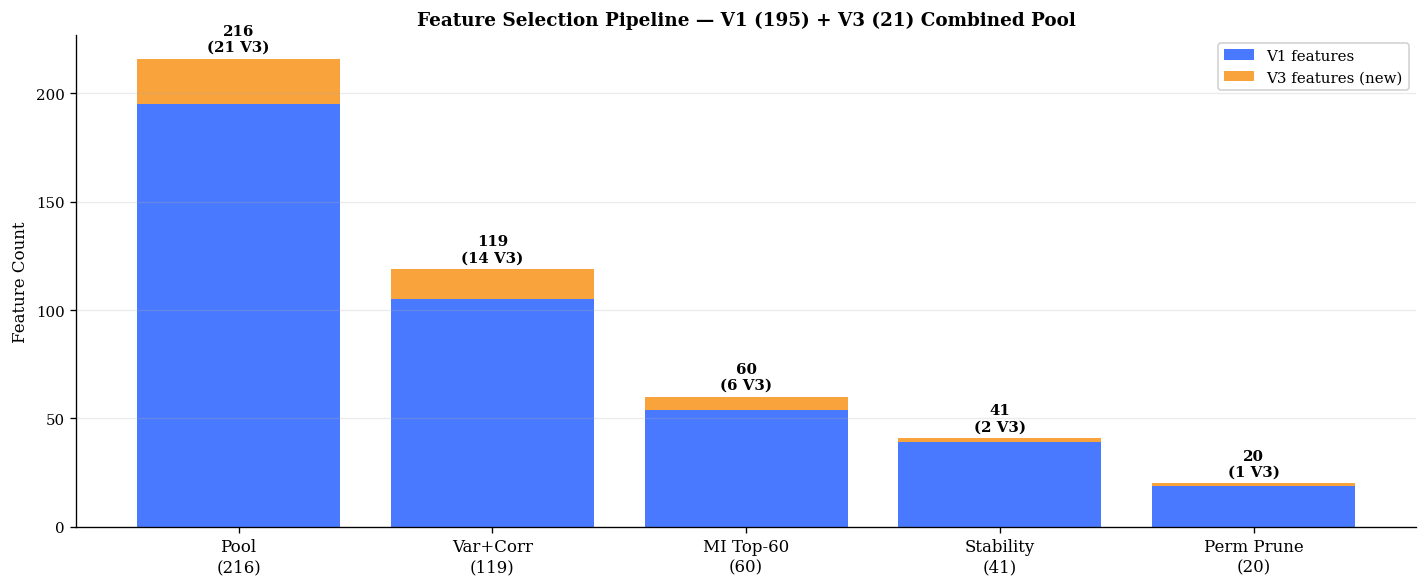

In [9]:
# ── Pipeline summary ──────────────────────────────────────────────────────────
print('FEATURE SELECTION PIPELINE SUMMARY')
print('─' * 55)
print(f'Stage 0 (Pool):      {len(ALL_FEATURE_COLS):>4}  ({len(V1_FEATURE_COLS)} V1 + {len(V3_FEATURE_COLS)} V3)')
print(f'Stage 1 (Filter):    {len(stage1):>4}  ({len(v3_in_s1)} V3)')
print(f'Stage 2 (MI Rank):   {len(stage2):>4}  ({n_v3_s2} V3)')
print(f'Stage 3 (Stability): {len(stage3):>4}  ({len(v3_in_s3)} V3)')
print(f'Stage 4 (Prune):     {len(SELECTED_FEATURES):>4}  ({len(v3_in_s4)} V3)')
print(f'\nFinal feature set ({len(SELECTED_FEATURES)} features):')
for i, f in enumerate(SELECTED_FEATURES):
    tag = '[V3]' if f in V3_FEATURE_COLS else '    '
    print(f'  {i+1:>2}. {tag} {f}')

# ── Funnel chart ──────────────────────────────────────────────────────────────
stage_labels = [
    f'Pool\n({len(ALL_FEATURE_COLS)})',
    f'Var+Corr\n({len(stage1)})',
    f'MI Top-60\n({len(stage2)})',
    f'Stability\n({len(stage3)})',
    f'Perm Prune\n({len(SELECTED_FEATURES)})',
]
counts    = [len(ALL_FEATURE_COLS), len(stage1), len(stage2), len(stage3), len(SELECTED_FEATURES)]
v3_counts = [len(V3_FEATURE_COLS),  len(v3_in_s1), n_v3_s2,  len(v3_in_s3), len(v3_in_s4)]
v1_counts = [c - v for c, v in zip(counts, v3_counts)]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stage_labels))
ax.bar(x, v1_counts, color=BLUE,  alpha=0.85, label='V1 features')
ax.bar(x, v3_counts, bottom=v1_counts, color=ACCENT, alpha=0.85, label='V3 features (new)')
for xi, (c, v) in enumerate(zip(counts, v3_counts)):
    ax.text(xi, c + max(counts) * 0.01, f'{c}\n({v} V3)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.set_ylabel('Feature Count')
ax.set_title(
    f'Feature Selection Pipeline — V1 ({len(V1_FEATURE_COLS)}) + V3 ({len(V3_FEATURE_COLS)}) Combined Pool',
    fontweight='bold',
)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(ARTS_DIR / '00_pipeline_funnel.png')
plt.show()

---
## Phase 2 — Walk-Forward Optimization (4 Schemes)

Each scheme trains a fresh LightGBM every 720 bars (1 month), predicting on the next 720.
Probabilities are generated for the full OOS period (2024-01-01 onward).

| Scheme | Training window |
|--------|-----------------|
| EXP | All history (expanding) |
| L2Y | Last 2 years (17 520 bars) |
| M1Y | Last 1 year (8 760 bars) |
| S3M | Last 3 months (2 160 bars) |


In [10]:
print('=' * 65)
print('PHASE 2 — WALK-FORWARD OPTIMIZATION')
print('=' * 65)

WFO_SCHEMES = {
    'EXP': {'name': 'Expanding (All History)', 'train_bars': None,  'color': BLUE},
    'L2Y': {'name': '2-Year Sliding',          'train_bars': 17520, 'color': ACCENT},
    'M1Y': {'name': '1-Year Sliding',          'train_bars': 8760,  'color': GREEN},
    'S3M': {'name': '3-Month Sliding',         'train_bars': 2160,  'color': RED},
}

BASE_LGBM_PARAMS = dict(
    num_leaves=31, max_depth=6, learning_rate=0.05,
    colsample_bytree=0.7, min_child_samples=50, subsample=0.7,
    reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
)

oos_df = merged[oos_mask].copy()
print(f'OOS period : {oos_df.index.min().date()} → {oos_df.index.max().date()}')
print(f'OOS bars   : {len(oos_df):,}')
print(f'Features   : {len(SELECTED_FEATURES)}')
print(f'\nWFO schemes:')
for sk, sc in WFO_SCHEMES.items():
    tb = f'{sc["train_bars"]:,} bars' if sc['train_bars'] else 'all past data'
    print(f'  {sk}: {sc["name"]:<28}  train={tb}')

PHASE 2 — WALK-FORWARD OPTIMIZATION
OOS period : 2024-01-01 → 2026-05-16
OOS bars   : 20,785
Features   : 20

WFO schemes:
  EXP: Expanding (All History)       train=all past data
  L2Y: 2-Year Sliding                train=17,520 bars
  M1Y: 1-Year Sliding                train=8,760 bars
  S3M: 3-Month Sliding               train=2,160 bars


In [11]:
def run_wfo(
    scheme_key: str,
    lgbm_params: dict = None,
    verbose: bool = True,
) -> pd.Series:
    """Walk-forward optimization for one training-window scheme.

    Returns OOS probability series indexed by timestamp.
    """
    if lgbm_params is None:
        lgbm_params = BASE_LGBM_PARAMS
    scheme = WFO_SCHEMES[scheme_key]

    n_oos     = len(oos_df)
    probs_all = np.full(n_oos, np.nan)
    n_fits    = 0

    step = 0
    while step * STEP_SIZE < n_oos:
        t0_pos = step * STEP_SIZE
        t1_pos = min((step + 1) * STEP_SIZE, n_oos)

        # Absolute index in merged for the first test bar
        first_test_ts = oos_df.index[t0_pos]
        abs_test_start = merged.index.searchsorted(first_test_ts)

        train_end_abs = abs_test_start - EMBARGO
        if train_end_abs < 300:
            step += 1
            continue

        if scheme['train_bars'] is None:
            train_start_abs = 0
        else:
            train_start_abs = max(0, train_end_abs - scheme['train_bars'])

        train_slice = merged.iloc[train_start_abs:train_end_abs]
        if len(train_slice) < 300:
            step += 1
            continue

        val_n = max(100, int(len(train_slice) * VAL_FRAC))
        tr = train_slice.iloc[:-val_n]
        va = train_slice.iloc[-val_n:]

        if tr[LABEL_COL].nunique() < 2 or va[LABEL_COL].nunique() < 2:
            step += 1
            continue

        X_tr = tr[SELECTED_FEATURES].fillna(0).values
        y_tr = tr[LABEL_COL].values
        X_va = va[SELECTED_FEATURES].fillna(0).values
        y_va = va[LABEL_COL].values

        model = lgb.LGBMClassifier(
            **lgbm_params, verbose=-1, random_state=42, n_jobs=-1
        )
        model.fit(
            X_tr, y_tr, eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(30, verbose=False)],
        )

        X_test = oos_df.iloc[t0_pos:t1_pos][SELECTED_FEATURES].fillna(0).values
        probs  = model.predict_proba(X_test)[:, 1]
        probs_all[t0_pos:t1_pos] = probs
        n_fits += 1
        step   += 1

    if verbose:
        print(f'  [{scheme_key}] {scheme["name"]}: {n_fits} WFO fits')
    return pd.Series(probs_all, index=oos_df.index, name=scheme_key)

In [12]:
wfo_probs = {}
t_all = time.time()

for sk in WFO_SCHEMES:
    print(f'\n{"─"*60}')
    print(f'Running {sk}: {WFO_SCHEMES[sk]["name"]}')
    probs = run_wfo(sk)
    wfo_probs[sk] = probs

elapsed = time.time() - t_all
print(f'\nAll 4 WFO schemes done in {elapsed/60:.1f} min')


────────────────────────────────────────────────────────────
Running EXP: Expanding (All History)
  [EXP] Expanding (All History): 29 WFO fits

────────────────────────────────────────────────────────────
Running L2Y: 2-Year Sliding
  [L2Y] 2-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running M1Y: 1-Year Sliding
  [M1Y] 1-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running S3M: 3-Month Sliding
  [S3M] 3-Month Sliding: 29 WFO fits

All 4 WFO schemes done in 0.7 min


In [13]:
y_oos = oos_df[LABEL_COL].values


def _equity_from_probs(
    probs_arr,
    threshold=DEFAULT_THRESHOLD,
    entry_atr_mult=DEFAULT_ENTRY_ATR,
    sl_mult=DEFAULT_SL_MULT,
    tp_mult=DEFAULT_TP_MULT,
    max_hold=DEFAULT_MAX_HOLD,
    cooldown_bars=DEFAULT_COOLDOWN,
):
    """Long-only ATR-stop equity from probability array."""
    n         = len(oos_df)
    close_arr = oos_df['close'].values
    high_arr  = oos_df['high'].values
    low_arr   = oos_df['low'].values
    atr_arr   = oos_df['atr_14_pct'].values

    equity_arr = np.ones(n)
    cur_eq     = 1.0
    in_pos     = False
    pos_eq     = 1.0
    entry_px   = sl_px = tp_px = 0.0
    entry_bar  = hold_count = cooldown_count = 0
    pending    = None  # (limit_px, sl_px, tp_px)

    for i in range(n):
        if in_pos:
            hold_count += 1
            lo = low_arr[i]; hi = high_arr[i]
            equity_arr[i] = pos_eq * close_arr[i] / entry_px  # mark-to-market
            exited = False; exit_px = 0.0
            if lo <= sl_px:                           exit_px = sl_px;         exited = True
            elif hi >= tp_px:                          exit_px = tp_px;         exited = True
            elif hold_count >= max_hold:               exit_px = close_arr[i];  exited = True
            if exited:
                cur_eq = pos_eq * (exit_px / entry_px)
                equity_arr[i] = cur_eq
                in_pos = False; cooldown_count = cooldown_bars

        elif pending is not None:
            lim_px, p_sl, p_tp = pending
            entry_px = lim_px if low_arr[i] <= lim_px else close_arr[i]
            sl_px = p_sl; tp_px = p_tp
            in_pos = True; pos_eq = cur_eq; entry_bar = i; hold_count = 0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs_arr[i]) and probs_arr[i] > threshold and i + 1 < n:
            atr = atr_arr[i]; px = close_arr[i]
            pending = (
                px * (1 - entry_atr_mult * atr),
                px * (1 - sl_mult * atr),
                px * (1 + tp_mult * atr),
            )
            equity_arr[i] = cur_eq

        else:
            equity_arr[i] = cur_eq

    if in_pos:
        cur_eq = pos_eq * (close_arr[-1] / entry_px)
        equity_arr[-1] = cur_eq
    return equity_arr


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


wfo_metrics = {}
print(f'{"Scheme":<6}  {"Name":<28}  {"AUC":>6}  {"Sharpe":>7}  {"Return":>8}  {"MaxDD":>7}  {"Signals":>8}')
print('─' * 80)

for sk, probs_s in wfo_probs.items():
    pa    = probs_s.values
    valid = ~np.isnan(pa)
    auc   = roc_auc_score(y_oos[valid], pa[valid]) if valid.sum() > 100 else 0.5
    eq    = _equity_from_probs(pa)
    sh    = _sharpe(eq)
    dd    = _maxdd(eq)
    ret   = eq[-1] - 1
    nsig  = int((pa[valid] > DEFAULT_THRESHOLD).sum())
    wfo_metrics[sk] = {'auc': auc, 'sharpe': sh, 'total_ret': ret,
                       'maxdd': dd, 'equity': eq, 'n_signals': nsig}
    print(f'{sk:<6}  {WFO_SCHEMES[sk]["name"]:<28}  {auc:.4f}  {sh:>7.3f}  '
          f'{ret:>+7.1%}  {dd:>7.1%}  {nsig:>8}')

# Buy & Hold baseline
bh_eq = oos_df['close'].values / oos_df['close'].iloc[0]
print(f'\nBuy & Hold: return={bh_eq[-1]-1:+.1%}  sharpe={_sharpe(bh_eq):.3f}  maxdd={_maxdd(bh_eq):.1%}')

BEST_SCHEME = max(wfo_metrics, key=lambda k: wfo_metrics[k]['auc'])
print(f'\n★ Best WFO scheme by OOS AUC: {BEST_SCHEME} ({WFO_SCHEMES[BEST_SCHEME]["name"]})')

Scheme  Name                             AUC   Sharpe    Return    MaxDD   Signals
────────────────────────────────────────────────────────────────────────────────
EXP     Expanding (All History)       0.5484    0.608   +52.5%   -23.4%      5297
L2Y     2-Year Sliding                0.5437    0.242   +17.6%   -24.0%      4243
M1Y     1-Year Sliding                0.5404    0.322   +21.6%   -26.0%      3406
S3M     3-Month Sliding               0.5273    1.151   +84.5%   -16.1%      2700

Buy & Hold: return=+86.3%  sharpe=0.542  maxdd=-50.1%

★ Best WFO scheme by OOS AUC: EXP (Expanding (All History))


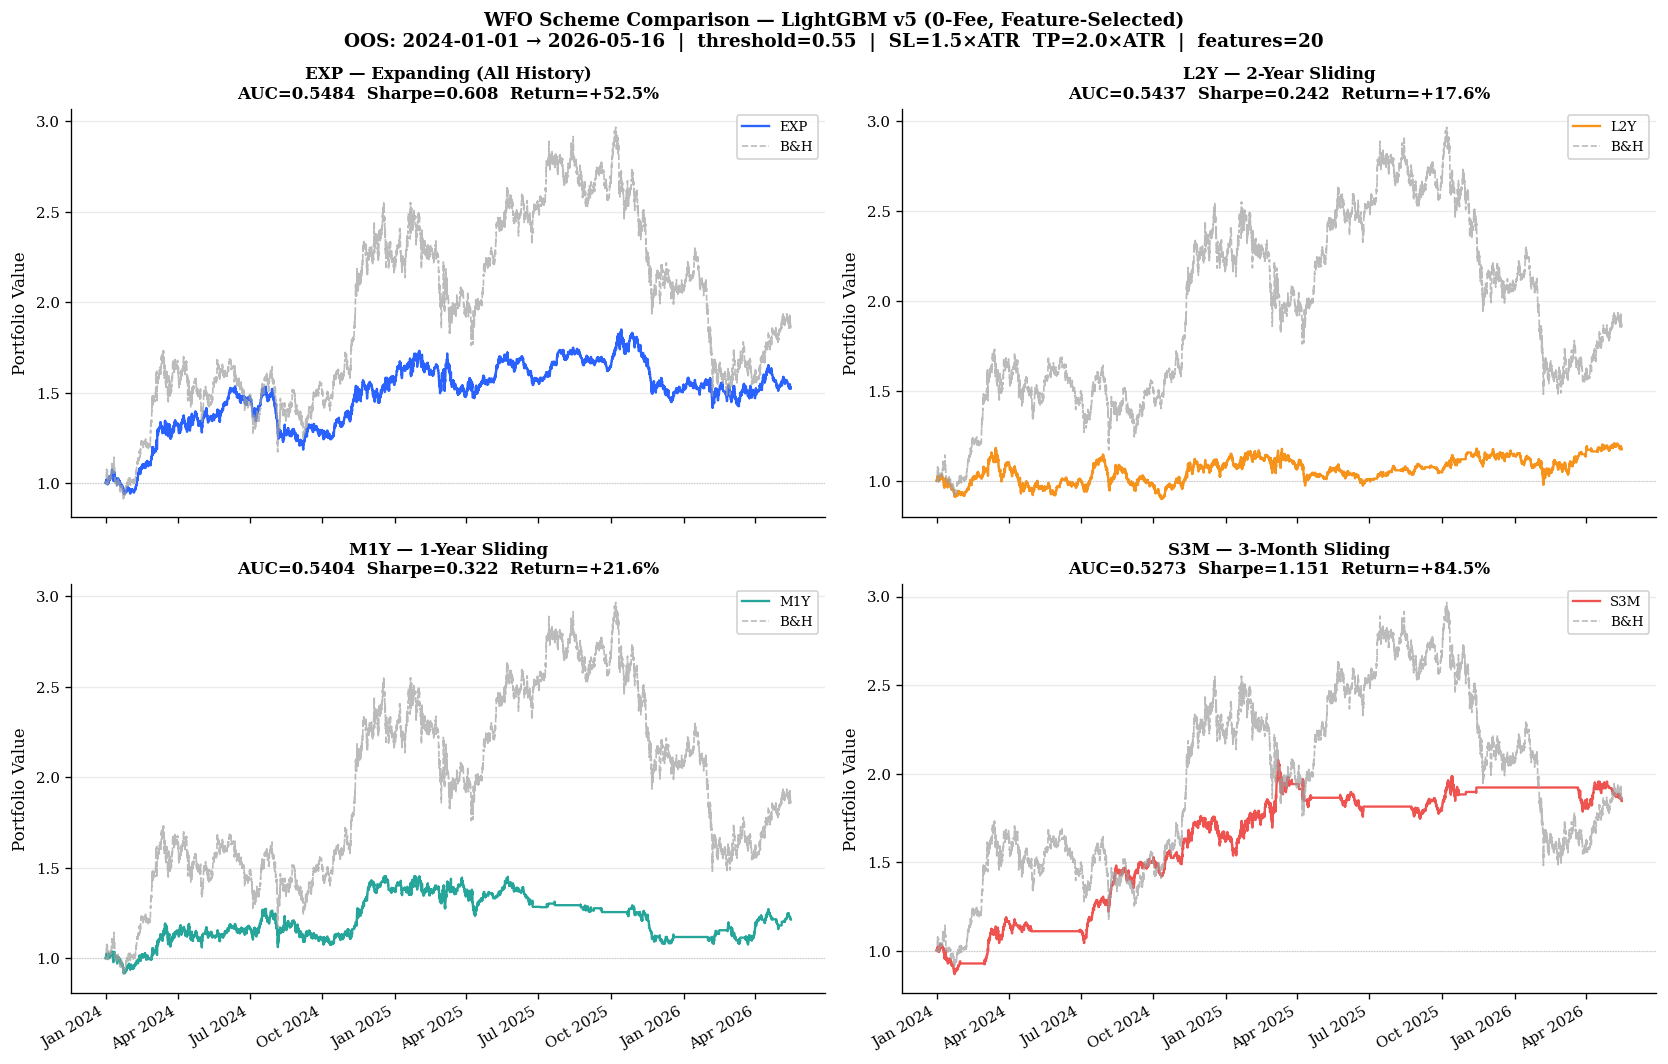

In [14]:
oos_index = oos_df.index

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (sk, scheme) in zip(axes, WFO_SCHEMES.items()):
    m  = wfo_metrics[sk]
    eq = m['equity']
    ax.plot(oos_index, eq,    color=scheme['color'], lw=1.4, label=sk)
    ax.plot(oos_index, bh_eq, color=GREY, lw=1.0, ls='--', alpha=0.7, label='B&H')
    ax.axhline(1.0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    ax.set_title(
        f'{sk} — {scheme["name"]}\n'
        f'AUC={m["auc"]:.4f}  Sharpe={m["sharpe"]:.3f}  Return={m["total_ret"]:+.1%}',
        fontsize=10, fontweight='bold',
    )
    ax.set_ylabel('Portfolio Value')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'WFO Scheme Comparison — LightGBM v5 (0-Fee, Feature-Selected)\n'
    f'OOS: {oos_df.index.min().date()} → {oos_df.index.max().date()}  '
    f'|  threshold={DEFAULT_THRESHOLD}  '
    f'|  SL={DEFAULT_SL_MULT}×ATR  TP={DEFAULT_TP_MULT}×ATR  '
    f'|  features={len(SELECTED_FEATURES)}',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '01_wfo_scheme_comparison.png')
plt.show()

---
## Phase 3 — Parameter Grid Search

Search 16 parameter combinations on the **best WFO scheme** (highest OOS AUC from Phase 2).  
Grid: `num_leaves` × `max_depth` × `learning_rate` × `colsample_bytree` = 2×2×2×2 = 16 combos.


In [15]:
print('=' * 65)
print(f'PHASE 3 — GRID SEARCH ON BEST SCHEME: {BEST_SCHEME}')
print('=' * 65)

PARAM_GRID = {
    'num_leaves':        [15, 31],
    'max_depth':         [6, 8],
    'learning_rate':     [0.03, 0.05],
    'colsample_bytree':  [0.5, 0.7],
    'min_child_samples': [50],
    'subsample':         [0.7],
    'reg_alpha':         [0.1],
    'reg_lambda':        [1.0],
    'n_estimators':      [500],
}

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*[PARAM_GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos)}')

grid_results = []
t_grid = time.time()

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    if (i + 1) % 4 == 1:
        print(f'  Combo {i+1:>2}/{len(combos)}  ...  ({time.time()-t_grid:.0f}s elapsed)')

    probs_s  = run_wfo(BEST_SCHEME, lgbm_params=params, verbose=False)
    pa       = probs_s.values
    valid    = ~np.isnan(pa)
    if valid.sum() < 100:
        continue

    auc    = roc_auc_score(y_oos[valid], pa[valid])
    eq     = _equity_from_probs(pa)
    n_sig  = int((pa[valid] > DEFAULT_THRESHOLD).sum())
    grid_results.append({
        **params,
        'auc':       auc,
        'sharpe':    _sharpe(eq),
        'total_ret': eq[-1] - 1,
        'maxdd':     _maxdd(eq),
        'n_trades':  n_sig,
    })

grid_df = pd.DataFrame(grid_results).sort_values('auc', ascending=False).reset_index(drop=True)
print(f'\nGrid search done in {(time.time()-t_grid)/60:.1f} min')
print(f'\nTop 10 by OOS AUC:')
disp = ['num_leaves','max_depth','learning_rate','colsample_bytree','auc','sharpe','total_ret','n_trades']
print(grid_df[[c for c in disp if c in grid_df.columns]].head(10).to_string(index=False))

# Cast integer params back from DataFrame floats → ints before passing to LightGBM
_INT_KEYS = {'num_leaves', 'max_depth', 'min_child_samples', 'n_estimators'}
BEST_PARAMS = {
    k: int(grid_df.iloc[0][k]) if k in _INT_KEYS else float(grid_df.iloc[0][k])
    for k in keys
}
print(f'\n★ Best params: {BEST_PARAMS}')
print(f'  OOS AUC    : {grid_df.iloc[0]["auc"]:.4f}')
print(f'  OOS Sharpe : {grid_df.iloc[0]["sharpe"]:.3f}')
print(f'  OOS Return : {grid_df.iloc[0]["total_ret"]:+.2%}')

PHASE 3 — GRID SEARCH ON BEST SCHEME: EXP
Grid combinations: 16
  Combo  1/16  ...  (0s elapsed)
  Combo  5/16  ...  (70s elapsed)
  Combo  9/16  ...  (144s elapsed)
  Combo 13/16  ...  (235s elapsed)

Grid search done in 5.6 min

Top 10 by OOS AUC:
 num_leaves  max_depth  learning_rate  colsample_bytree    auc  sharpe  total_ret  n_trades
         31          8         0.0300            0.5000 0.5491  0.6317     0.5455      5249
         31          8         0.0500            0.5000 0.5490  0.7142     0.6365      5526
         31          8         0.0500            0.7000 0.5490  1.0764     1.1083      5252
         31          8         0.0300            0.7000 0.5489  0.4472     0.3598      5387
         31          6         0.0500            0.5000 0.5487  0.8408     0.7930      5312
         31          6         0.0300            0.5000 0.5485  0.4520     0.3631      5345
         31          6         0.0500            0.7000 0.5484  0.6083     0.5252      5297
         15   

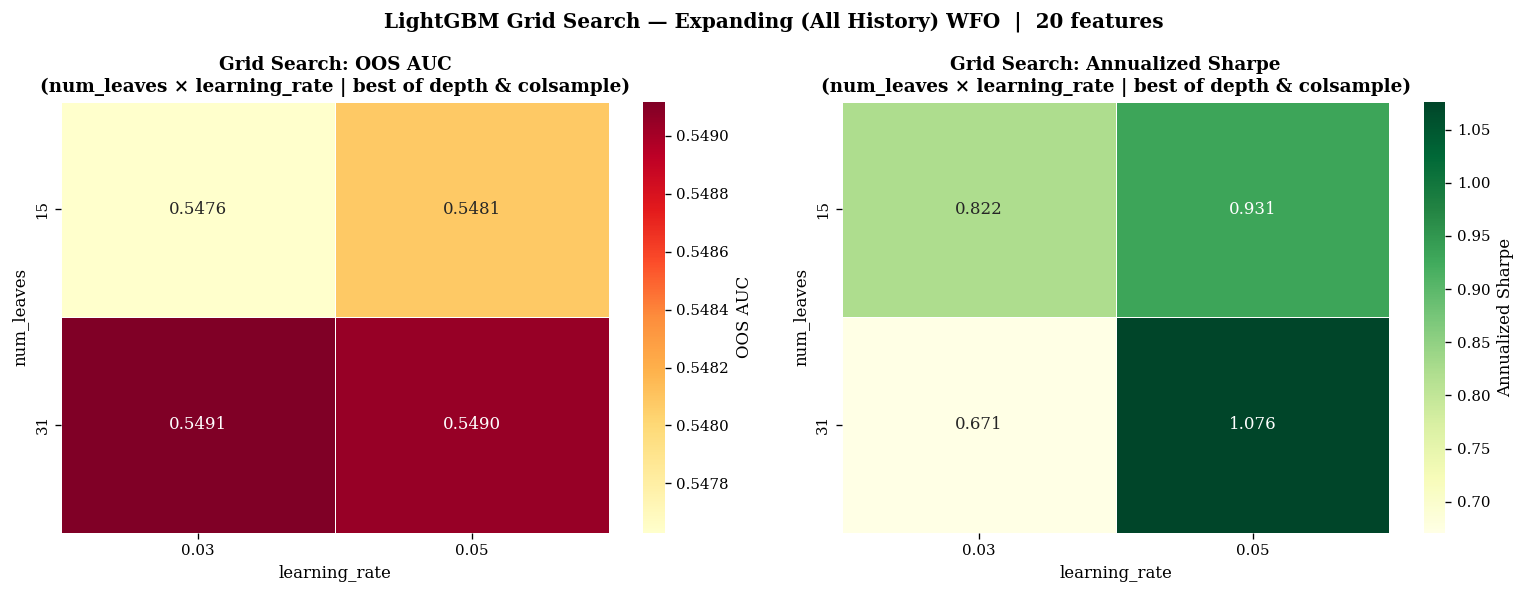

In [16]:
pivot_auc    = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='auc',    aggfunc='max')
pivot_sharpe = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='sharpe', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_auc,    ax=axes[0], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'OOS AUC'})
axes[0].set_title(
    f'Grid Search: OOS AUC\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[0].set_xlabel('learning_rate'); axes[0].set_ylabel('num_leaves')

sns.heatmap(pivot_sharpe, ax=axes[1], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Annualized Sharpe'})
axes[1].set_title(
    f'Grid Search: Annualized Sharpe\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[1].set_xlabel('learning_rate'); axes[1].set_ylabel('num_leaves')

fig.suptitle(
    f'LightGBM Grid Search — {WFO_SCHEMES[BEST_SCHEME]["name"]} WFO  |  {len(SELECTED_FEATURES)} features',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '02_grid_search_heatmap.png')
plt.show()

---
## Phase 3.5 — ATH-Window Detection

The Phase 4 backtest starts from the **first bar where BTC close ≥ the last OOS close price** — i.e., when BTC first reached the ATH level seen at the end of the testing period.  
This avoids backtesting over a period of price discovery that predates the current price regime.


In [17]:
# ── ATH-Window: start from when BTC first reached the end-of-OOS price ────────
oos_df = merged[oos_mask].copy()
_end_price = oos_df['close'].iloc[-1]

# First bar (across all history including pre-OOS) where close >= end_price
_ath_hits = merged[merged['close'] >= _end_price]
if len(_ath_hits) > 0:
    ATH_START = _ath_hits.index[0]
else:
    ATH_START = oos_df.index[0]
    print('WARNING: BTC never reached end-of-OOS price in dataset. Using OOS start.')

print(f'Last OOS close price      : ${_end_price:,.2f}')
print(f'BTC first hit this level  : {ATH_START}')

# Slice OOS to ATH-window (used for all Phase 4+ backtesting)
oos_v6 = merged[merged.index >= ATH_START].copy()
n_v6   = len(oos_v6)

print(f'\nV6 backtest window: {oos_v6.index.min().date()} → {oos_v6.index.max().date()}')
print(f'V6 backtest bars  : {n_v6:,}')

# Slice best-params probs to V6 window (will be filled after Phase 3 re-run)
# Buy & hold baseline for V6 window
bh_v6 = oos_v6['close'].values / oos_v6['close'].iloc[0]
print(f'Buy & Hold over V6: {bh_v6[-1]-1:+.2%}')


Last OOS close price      : $79,111.92
BTC first hit this level  : 2024-11-10 04:00:00

V6 backtest window: 2024-11-10 → 2026-05-16
V6 backtest bars  : 13,245
Buy & Hold over V6: -0.01%


---
## Phase 4 — Conviction-Weighted Leverage Backtest

**Leverage model** (linear mapping):

| Signal probability | Leverage |
|-------------------|----------|
| ≤ threshold (0.55) | no trade |
| 0.55 | 1× |
| 0.72 | ~10× |
| ≥ 0.90 | 20× (capped) |

**Safety cap**: leverage is clamped so a full SL hit can't wipe >90% of equity.  
At `SL = 1.5 × ATR_pct`, max safe leverage = `0.90 / (1.5 × atr_pct)`.

**Fee model** (Binance Perpetual Futures — applies to longs in v6):

| Order type | Fee per side | Fee on equity |
|------------|-------------|---------------|
| Limit (entry, TP) | 0.02% maker | 0.02% × leverage |
| Market (SL, timeout) | 0.05% taker | 0.05% × leverage |

Round-trip fee at 10× leverage: ~0.14% of equity (entry limit + exit market).


In [18]:
# ── Re-run WFO with best params to get probs ────────────────────────────────
print('=' * 65)
print('PHASE 4 — CONVICTION-WEIGHTED LEVERAGE BACKTEST')
print('=' * 65)

print(f'Re-running WFO ({BEST_SCHEME}) with best params on full OOS...')
best_probs_s = run_wfo(BEST_SCHEME, lgbm_params=BEST_PARAMS)

# Slice to ATH window
best_probs_v6 = best_probs_s.reindex(oos_v6.index)
y_v6 = oos_v6[LABEL_COL].values
pa_v6 = best_probs_v6.values
valid_v6 = ~np.isnan(pa_v6)
if valid_v6.sum() > 50:
    auc_v6 = roc_auc_score(y_v6[valid_v6], pa_v6[valid_v6])
    print(f'V6 window OOS AUC : {auc_v6:.4f}')
print(f'V6 window bars    : {len(oos_v6):,}')
print(f'Signals (p>thr)   : {int((pa_v6[valid_v6] > DEFAULT_THRESHOLD).sum())}')


def prob_to_leverage(
    prob: float,
    threshold: float,
    min_lev: float = DEFAULT_MIN_LEV,
    max_lev: float = DEFAULT_MAX_LEV,
    prob_high: float = LEV_PROB_HIGH,
) -> float:
    """Linear map: threshold→min_lev, prob_high→max_lev (vectorisable)."""
    if prob <= threshold:
        return 0.0
    frac = min((prob - threshold) / max(prob_high - threshold, 1e-9), 1.0)
    return min_lev + frac * (max_lev - min_lev)


def safety_cap_leverage(raw_lev: float, atr: float) -> float:
    """Cap leverage so a full SL hit loses at most LEV_MAX_LOSS_FRAC of equity."""
    max_safe = LEV_MAX_LOSS_FRAC / max(DEFAULT_SL_MULT * atr, 1e-6)
    return min(raw_lev, max_safe)


# Vectorised leverage array for diagnostics
_lev_vec = np.array([
    prob_to_leverage(p, DEFAULT_THRESHOLD) if not np.isnan(p) else 0.0
    for p in pa_v6
])
_sig_mask = _lev_vec > 0
if _sig_mask.sum() > 0:
    print(f'\nLeverage distribution over signals:')
    print(f'  Min   : {_lev_vec[_sig_mask].min():.1f}×')
    print(f'  Median: {np.median(_lev_vec[_sig_mask]):.1f}×')
    print(f'  Mean  : {_lev_vec[_sig_mask].mean():.1f}×')
    print(f'  Max   : {_lev_vec[_sig_mask].max():.1f}×')


PHASE 4 — CONVICTION-WEIGHTED LEVERAGE BACKTEST
Re-running WFO (EXP) with best params on full OOS...
  [EXP] Expanding (All History): 29 WFO fits
V6 window OOS AUC : 0.5450
V6 window bars    : 13,245
Signals (p>thr)   : 3164

Leverage distribution over signals:
  Min   : 1.0×
  Median: 2.4×
  Mean  : 2.7×
  Max   : 11.0×


In [19]:
def run_leveraged_backtest(
    df: pd.DataFrame,
    probs_series: pd.Series,
    threshold: float = DEFAULT_THRESHOLD,
    entry_atr_mult: float = DEFAULT_ENTRY_ATR,
    sl_mult: float = DEFAULT_SL_MULT,
    tp_mult: float = DEFAULT_TP_MULT,
    max_hold: int = DEFAULT_MAX_HOLD,
    cooldown_bars: int = DEFAULT_COOLDOWN,
    min_lev: float = DEFAULT_MIN_LEV,
    max_lev: float = DEFAULT_MAX_LEV,
    prob_high: float = LEV_PROB_HIGH,
    maker_fee: float = FUTURES_MAKER_FEE,
    taker_fee: float = FUTURES_TAKER_FEE,
    apply_safety_cap: bool = True,
) -> tuple:
    """Conviction-weighted leverage backtester with Binance Perpetual Futures fees.

    Leverage scales linearly with signal probability (threshold→min_lev, prob_high→max_lev).
    Fee cost as % of equity = fee_rate * leverage (fees applied on notional).
    PnL on equity = price_return * leverage - fee_cost.
    Liquidation floor: equity return capped at -100% per trade.
    """
    n         = len(df)
    close_arr = df['close'].values
    high_arr  = df['high'].values
    low_arr   = df['low'].values
    atr_arr   = df['atr_14_pct'].values
    probs     = probs_series.reindex(df.index).fillna(0).values

    equity_arr     = np.ones(n)
    cur_eq         = 1.0
    trade_log      = []

    in_pos         = False
    pos_eq         = 1.0
    entry_px       = sl_px = tp_px = 0.0
    entry_lev      = 1.0
    entry_fee_paid = 0.0
    entry_bar      = hold_count = cooldown_count = 0
    pending        = None  # (limit_px, sl_px, tp_px, leverage, prob)

    for i in range(n):
        if in_pos:
            hold_count += 1
            lo = low_arr[i]; hi = high_arr[i]
            price_ret = close_arr[i] / entry_px - 1
            equity_arr[i] = pos_eq * max(1 + price_ret * entry_lev, 0.0)  # mark-to-market

            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0
            if   lo <= sl_px:            exit_px = sl_px;        exited = True; reason = 'sl';      exit_fee = taker_fee
            elif hi >= tp_px:            exit_px = tp_px;        exited = True; reason = 'tp';      exit_fee = maker_fee
            elif hold_count >= max_hold: exit_px = close_arr[i]; exited = True; reason = 'timeout'; exit_fee = taker_fee

            if exited:
                price_ret  = exit_px / entry_px - 1
                gross_eq   = price_ret * entry_lev
                fee_cost   = (entry_fee_paid + exit_fee) * entry_lev  # % of equity
                net_eq_ret = max(gross_eq - fee_cost, -1.0)           # floor at -100%
                cur_eq     = pos_eq * (1.0 + net_eq_ret)
                equity_arr[i] = cur_eq
                trade_log.append({
                    'entry_bar':  entry_bar,  'exit_bar':  i,
                    'entry_time': df.index[entry_bar],
                    'exit_time':  df.index[i],
                    'entry_px':   float(entry_px),
                    'exit_px':    float(exit_px),
                    'leverage':   float(entry_lev),
                    'gross_pct':  float(gross_eq   * 100),
                    'fee_pct':    float(fee_cost   * 100),
                    'pnl_pct':    float(net_eq_ret * 100),
                    'reason':     reason,
                    'hold_bars':  hold_count,
                })
                in_pos = False; cooldown_count = cooldown_bars

        elif pending is not None:
            lim_px, p_sl, p_tp, lev, _prob = pending
            if low_arr[i] <= lim_px:
                entry_px = lim_px;        entry_fee_paid = maker_fee
            else:
                entry_px = close_arr[i];  entry_fee_paid = taker_fee
            sl_px = p_sl; tp_px = p_tp; entry_lev = lev
            in_pos = True; pos_eq = cur_eq; entry_bar = i; hold_count = 0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs[i]) and probs[i] > threshold and i + 1 < n:
            atr = atr_arr[i]; px = close_arr[i]
            raw_lev = prob_to_leverage(probs[i], threshold, min_lev, max_lev, prob_high)
            lev     = safety_cap_leverage(raw_lev, atr) if apply_safety_cap else raw_lev
            pending = (
                px * (1.0 - entry_atr_mult * atr),
                px * (1.0 - sl_mult        * atr),
                px * (1.0 + tp_mult        * atr),
                lev,
                probs[i],
            )
            equity_arr[i] = cur_eq
        else:
            equity_arr[i] = cur_eq

    if in_pos:
        price_ret  = close_arr[-1] / entry_px - 1
        fee_cost   = (entry_fee_paid + taker_fee) * entry_lev
        net_eq_ret = max(price_ret * entry_lev - fee_cost, -1.0)
        cur_eq     = pos_eq * (1.0 + net_eq_ret)
        equity_arr[-1] = cur_eq
        trade_log.append({
            'entry_bar': entry_bar, 'exit_bar': n - 1,
            'entry_time': df.index[entry_bar], 'exit_time': df.index[-1],
            'entry_px': float(entry_px), 'exit_px': float(close_arr[-1]),
            'leverage': float(entry_lev),
            'gross_pct': float(price_ret * entry_lev * 100),
            'fee_pct': float(fee_cost * 100),
            'pnl_pct': float(net_eq_ret * 100),
            'reason': 'eod', 'hold_bars': hold_count,
        })

    return equity_arr, pd.DataFrame(trade_log)


# ── Run backtest at two thresholds ───────────────────────────────────────────
eq_055, tdf_055 = run_leveraged_backtest(oos_v6, best_probs_v6, threshold=0.55)
eq_060, tdf_060 = run_leveraged_backtest(oos_v6, best_probs_v6, threshold=0.60)

print(f'\n{"":15}  {"Trades":>7}  {"WinRate":>8}  {"Return":>9}  {"Sharpe":>7}  {"MaxDD":>8}')
print('─' * 65)
for lbl, eq, tdf in [
    ('Lev p>0.55', eq_055, tdf_055),
    ('Lev p>0.60', eq_060, tdf_060),
]:
    wr = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0.0
    by_r = dict(tdf['reason'].value_counts()) if len(tdf) > 0 else {}
    print(f'{lbl:15}  {len(tdf):>7}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+8.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>8.2%}')
    if len(tdf) > 0:
        avg_lev = tdf['leverage'].mean()
        med_lev = tdf['leverage'].median()
        print(f'  Avg leverage: {avg_lev:.1f}×  Median: {med_lev:.1f}×  Exits: {by_r}')

bh_ret = bh_v6[-1] - 1
print(f'\nBuy & Hold (V6 window): {bh_ret:+.2%}  Sharpe={_sharpe(bh_v6):.3f}  MaxDD={_maxdd(bh_v6):.2%}')



                  Trades   WinRate     Return   Sharpe     MaxDD
─────────────────────────────────────────────────────────────────
Lev p>0.55           649     45.3%    -63.0%   -0.850   -78.47%
  Avg leverage: 2.4×  Median: 2.2×  Exits: {'sl': np.int64(346), 'tp': np.int64(282), 'timeout': np.int64(20), 'eod': np.int64(1)}
Lev p>0.60           255     47.8%    +30.8%    0.414   -31.33%
  Avg leverage: 2.1×  Median: 1.7×  Exits: {'sl': np.int64(130), 'tp': np.int64(121), 'timeout': np.int64(4)}

Buy & Hold (V6 window): -0.01%  Sharpe=-0.000  MaxDD=-50.08%


---
## Phase 5 — Visualizations


PHASE 5 — VISUALIZATIONS


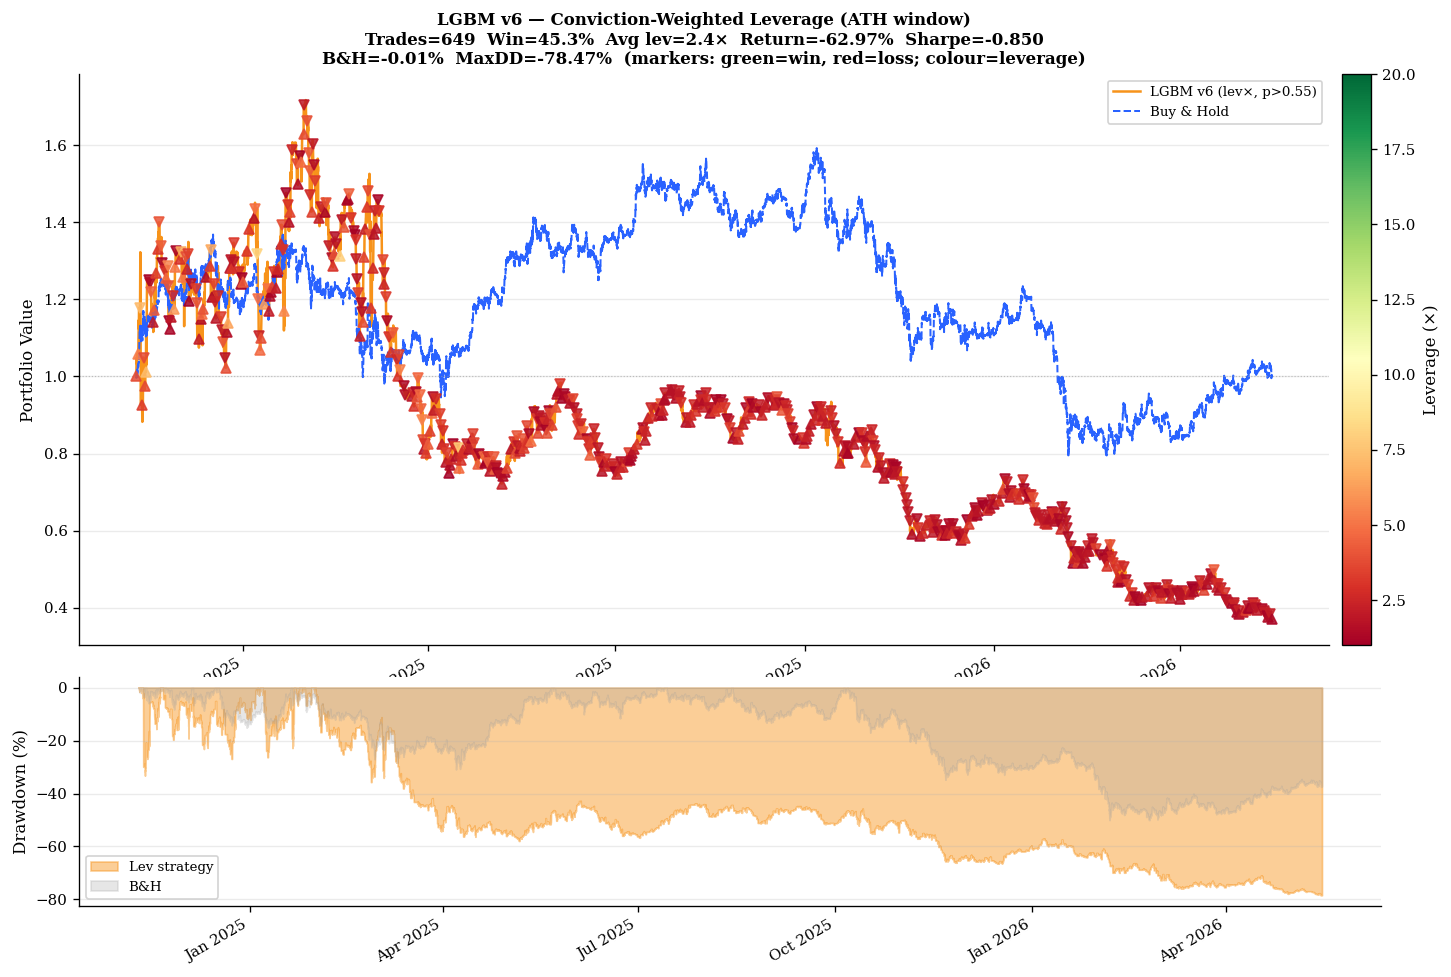

In [20]:
# ── Chart 1: Equity + Drawdown with trade leverage coloring ─────────────────
print('=' * 65)
print('PHASE 5 — VISUALIZATIONS')
print('=' * 65)

oos_v6_index = oos_v6.index
eq  = eq_055
tdf = tdf_055.copy() if len(tdf_055) > 0 else pd.DataFrame()

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08},
)

ax = axes[0]
ax.plot(oos_v6_index, eq,     color=ACCENT, lw=1.5,
        label=f'LGBM v6 (lev×, p>{DEFAULT_THRESHOLD})')
ax.plot(oos_v6_index, bh_v6,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':', alpha=0.6)

if len(tdf) > 0:
    cmap = plt.cm.RdYlGn
    lev_norm = plt.Normalize(vmin=1, vmax=DEFAULT_MAX_LEV)
    for _, row in tdf.iterrows():
        ib = int(row['entry_bar']); ob = int(row['exit_bar'])
        if ib >= len(oos_v6_index): continue
        color = cmap(lev_norm(row['leverage']))
        marker = '^' if row['pnl_pct'] > 0 else 'v'
        ax.plot(oos_v6_index[ib], eq[ib], marker=marker,
                color=color, ms=6, alpha=0.85, zorder=3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=lev_norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Leverage (×)', pad=0.01, fraction=0.03)

wr = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0.0
avg_lev = tdf['leverage'].mean() if len(tdf) > 0 else 0.0
ax.set_title(
    f'LGBM v6 — Conviction-Weighted Leverage (ATH window)\n'
    f'Trades={len(tdf)}  Win={wr:.1%}  Avg lev={avg_lev:.1f}×  '
    f'Return={eq[-1]-1:+.2%}  Sharpe={_sharpe(eq):.3f}\n'
    f'B&H={bh_v6[-1]-1:+.2%}  MaxDD={_maxdd(eq):.2%}  '
    f'(markers: green=win, red=loss; colour=leverage)',
    fontsize=10, fontweight='bold',
)
ax.set_ylabel('Portfolio Value')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.25)

ax_dd = axes[1]
pk    = np.maximum.accumulate(eq)
pk_bh = np.maximum.accumulate(bh_v6)
ax_dd.fill_between(oos_v6_index, (eq - pk) / (pk + 1e-12) * 100, 0,
                   color=ACCENT, alpha=0.45, label='Lev strategy')
ax_dd.fill_between(oos_v6_index, (bh_v6 - pk_bh) / (pk_bh + 1e-12) * 100, 0,
                   color=GREY, alpha=0.25, label='B&H')
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.legend(fontsize=8)
ax_dd.grid(axis='y', alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(ARTS_DIR / '01_equity_drawdown.png')
plt.show()


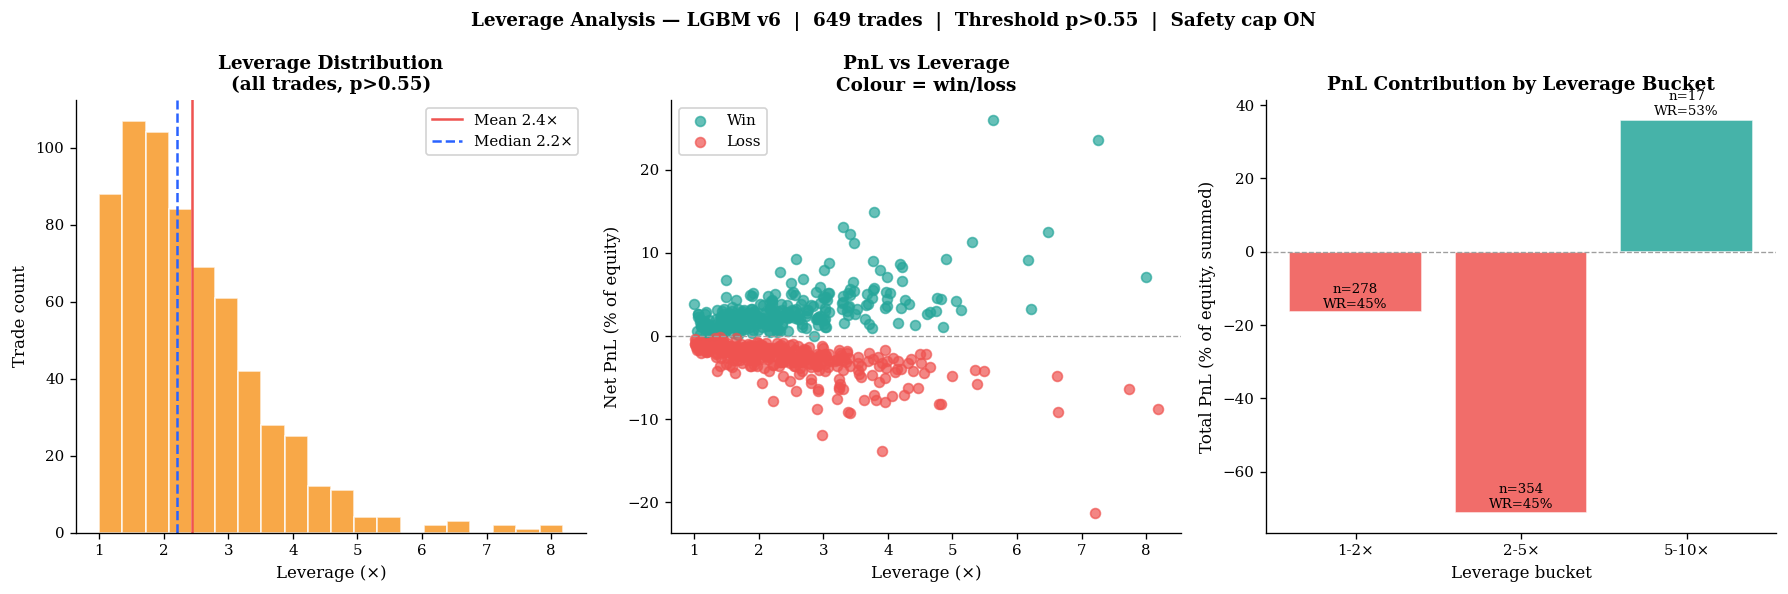

In [21]:
# ── Chart 2: Leverage distribution and PnL vs leverage scatter ───────────────
if len(tdf_055) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 2a — Leverage histogram
    ax = axes[0]
    ax.hist(tdf_055['leverage'], bins=20, color=ACCENT, alpha=0.80, edgecolor='white')
    ax.axvline(tdf_055['leverage'].mean(), color=RED, lw=1.5,
               label=f'Mean {tdf_055["leverage"].mean():.1f}×')
    ax.axvline(tdf_055['leverage'].median(), color=BLUE, lw=1.5, ls='--',
               label=f'Median {tdf_055["leverage"].median():.1f}×')
    ax.set_xlabel('Leverage (×)'); ax.set_ylabel('Trade count')
    ax.set_title('Leverage Distribution\n(all trades, p>0.55)', fontweight='bold')
    ax.legend()

    # 2b — PnL vs leverage scatter
    ax = axes[1]
    wins  = tdf_055[tdf_055['pnl_pct'] > 0]
    loses = tdf_055[tdf_055['pnl_pct'] <= 0]
    ax.scatter(wins['leverage'],  wins['pnl_pct'],  color=GREEN, alpha=0.7, s=35, label='Win')
    ax.scatter(loses['leverage'], loses['pnl_pct'], color=RED,   alpha=0.7, s=35, label='Loss')
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    ax.set_xlabel('Leverage (×)'); ax.set_ylabel('Net PnL (% of equity)')
    ax.set_title('PnL vs Leverage\nColour = win/loss', fontweight='bold')
    ax.legend()

    # 2c — Cumulative return contribution by leverage bucket
    ax = axes[2]
    tdf_055_c = tdf_055.copy()
    tdf_055_c['lev_bucket'] = pd.cut(
        tdf_055_c['leverage'],
        bins=[0, 2, 5, 10, 20],
        labels=['1-2×', '2-5×', '5-10×', '10-20×'],
    )
    bucket_stats = tdf_055_c.groupby('lev_bucket', observed=True).agg(
        n=('pnl_pct', 'count'),
        total_pnl=('pnl_pct', 'sum'),
        win_rate=('pnl_pct', lambda x: (x > 0).mean()),
    )
    colors = [BLUE, ACCENT, GREEN, RED]
    bars = ax.bar(bucket_stats.index.astype(str), bucket_stats['total_pnl'],
                  color=[GREEN if v > 0 else RED for v in bucket_stats['total_pnl']],
                  alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, bucket_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'n={int(row["n"])}\nWR={row["win_rate"]:.0%}',
                ha='center', va='bottom', fontsize=8)
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    ax.set_xlabel('Leverage bucket'); ax.set_ylabel('Total PnL (% of equity, summed)')
    ax.set_title('PnL Contribution by Leverage Bucket', fontweight='bold')

    fig.suptitle(
        f'Leverage Analysis — LGBM v6  |  {len(tdf_055)} trades  |  '
        f'Threshold p>0.55  |  Safety cap ON',
        fontweight='bold', fontsize=11,
    )
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '02_leverage_analysis.png')
    plt.show()


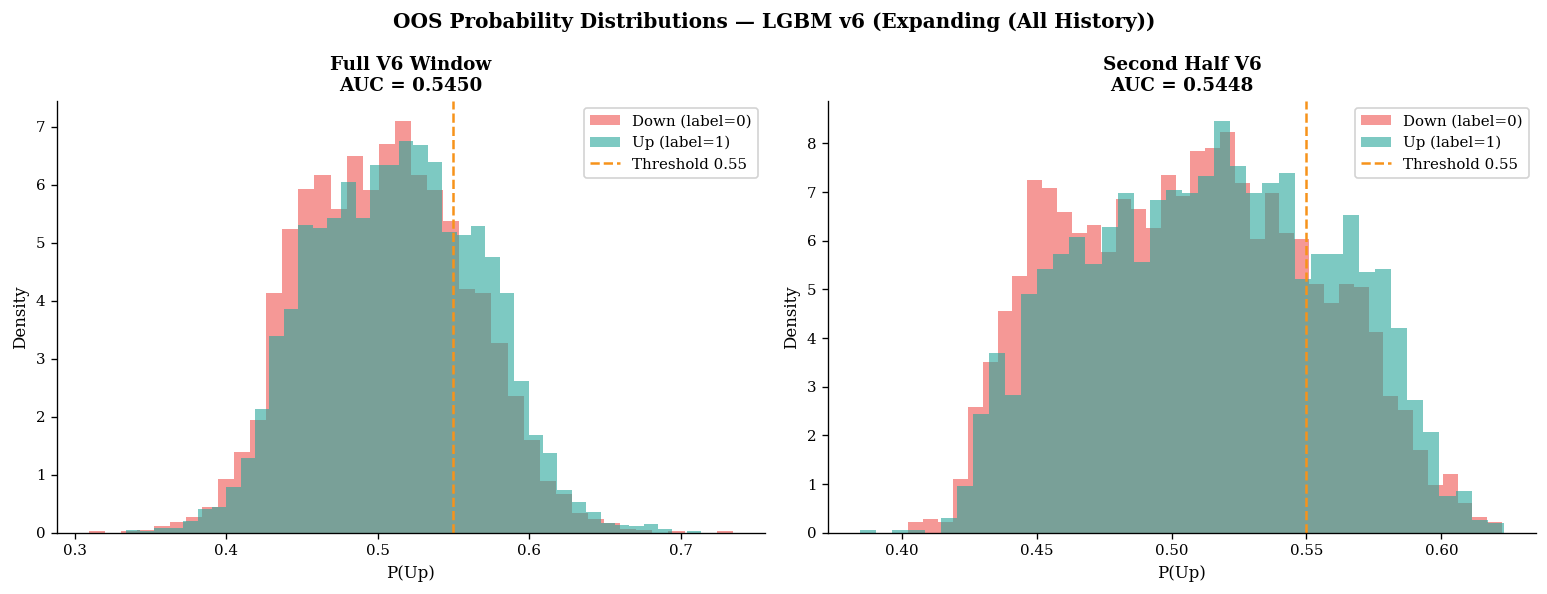

In [22]:
# ── Chart 3: Probability distributions — class 0 vs class 1 ─────────────────
pa    = best_probs_v6.values
valid = ~np.isnan(pa)
n_v6_bars = len(y_v6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

half = n_v6_bars // 2
splits = [
    ('Full V6 Window', valid),
    ('Second Half V6', np.concatenate([np.zeros(half, bool),
                                       np.ones(n_v6_bars - half, bool)]) & valid),
]

for ax, (title, mask) in zip(axes, splits):
    y_sub = y_v6[mask]
    p_sub = pa[mask]
    if len(p_sub) < 10 or len(np.unique(y_sub)) < 2:
        ax.set_title(f'{title}\n(insufficient data)')
        continue
    auc_sub = roc_auc_score(y_sub, p_sub)
    ax.hist(p_sub[y_sub == 0], bins=40, alpha=0.60, label='Down (label=0)',
            color=RED, density=True)
    ax.hist(p_sub[y_sub == 1], bins=40, alpha=0.60, label='Up (label=1)',
            color=GREEN, density=True)
    ax.axvline(DEFAULT_THRESHOLD, color=ACCENT, lw=1.5, ls='--',
               label=f'Threshold {DEFAULT_THRESHOLD}')
    ax.set_xlabel('P(Up)'); ax.set_ylabel('Density')
    ax.set_title(f'{title}\nAUC = {auc_sub:.4f}', fontweight='bold')
    ax.legend()

fig.suptitle(f'OOS Probability Distributions — LGBM v6 ({WFO_SCHEMES[BEST_SCHEME]["name"]})',
             fontweight='bold')
fig.tight_layout()
fig.savefig(ARTS_DIR / '03_prob_distributions.png')
plt.show()


Training final model for feature importance...
  Best iteration: 239


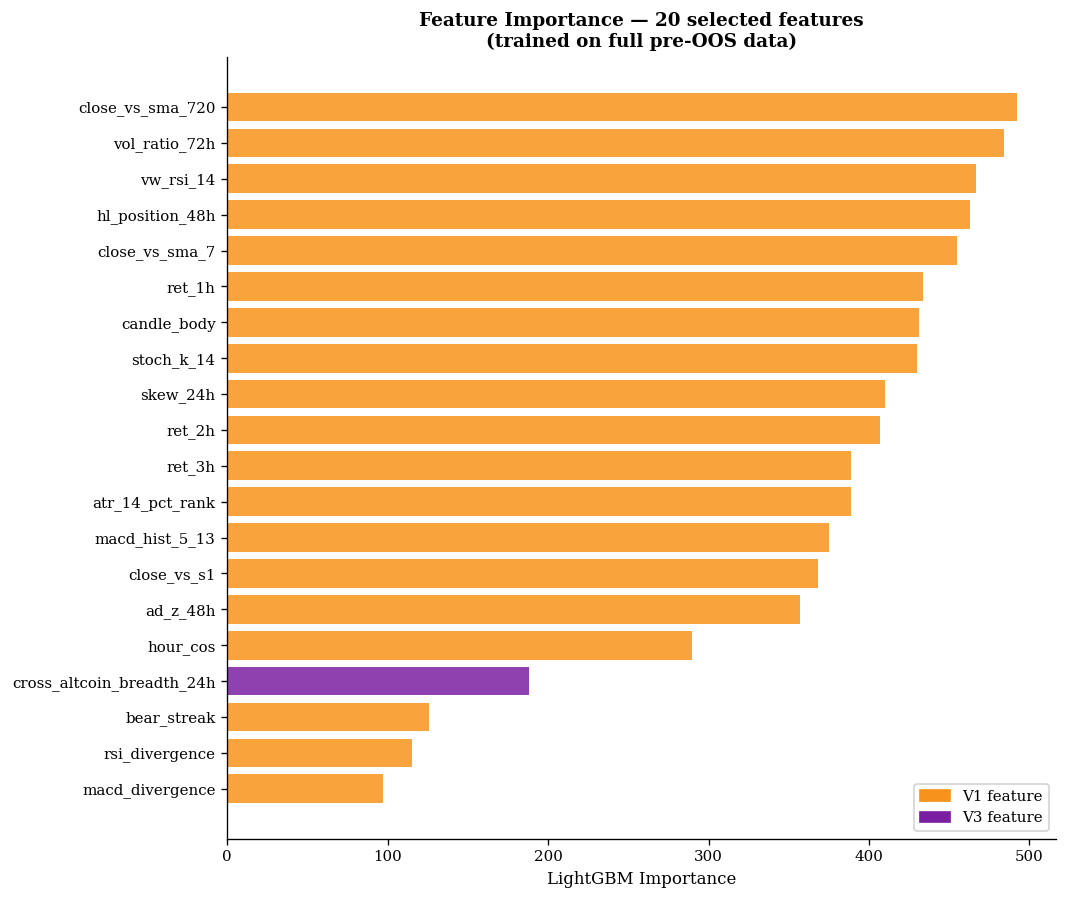

In [23]:
# ── Chart 4: Feature importance — train final model on all pre-OOS data ───────
print('Training final model for feature importance...')
train_full  = merged[~oos_mask]
val_n_final = max(500, int(len(train_full) * 0.15))
X_tr_f = train_full.iloc[:-val_n_final][SELECTED_FEATURES].fillna(0).values
y_tr_f = train_full.iloc[:-val_n_final][LABEL_COL].values
X_va_f = train_full.iloc[-val_n_final:][SELECTED_FEATURES].fillna(0).values
y_va_f = train_full.iloc[-val_n_final:][LABEL_COL].values

final_model = lgb.LGBMClassifier(
    **{k: BEST_PARAMS[k] for k in keys},
    verbose=-1, random_state=42, n_jobs=-1,
)
final_model.fit(
    X_tr_f, y_tr_f, eval_set=[(X_va_f, y_va_f)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)
print(f'  Best iteration: {final_model.best_iteration_}')

lgb_imp = pd.DataFrame({
    'feature':    SELECTED_FEATURES,
    'importance': final_model.feature_importances_,
    'is_v3':      [f in V3_FEATURE_COLS for f in SELECTED_FEATURES],
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(lgb_imp) * 0.38)))
colors = [PURPLE if v else ACCENT for v in lgb_imp['is_v3']]
ax.barh(lgb_imp['feature'], lgb_imp['importance'], color=colors, alpha=0.85)
v1_patch = mpatches.Patch(color=ACCENT,  label='V1 feature')
v3_patch = mpatches.Patch(color=PURPLE, label='V3 feature')
ax.legend(handles=[v1_patch, v3_patch], fontsize=9)
ax.set_xlabel('LightGBM Importance')
ax.set_title(f'Feature Importance — {len(SELECTED_FEATURES)} selected features\n'
             f'(trained on full pre-OOS data)', fontweight='bold')
fig.tight_layout()
fig.savefig(ARTS_DIR / '04_feature_importance.png')
plt.show()


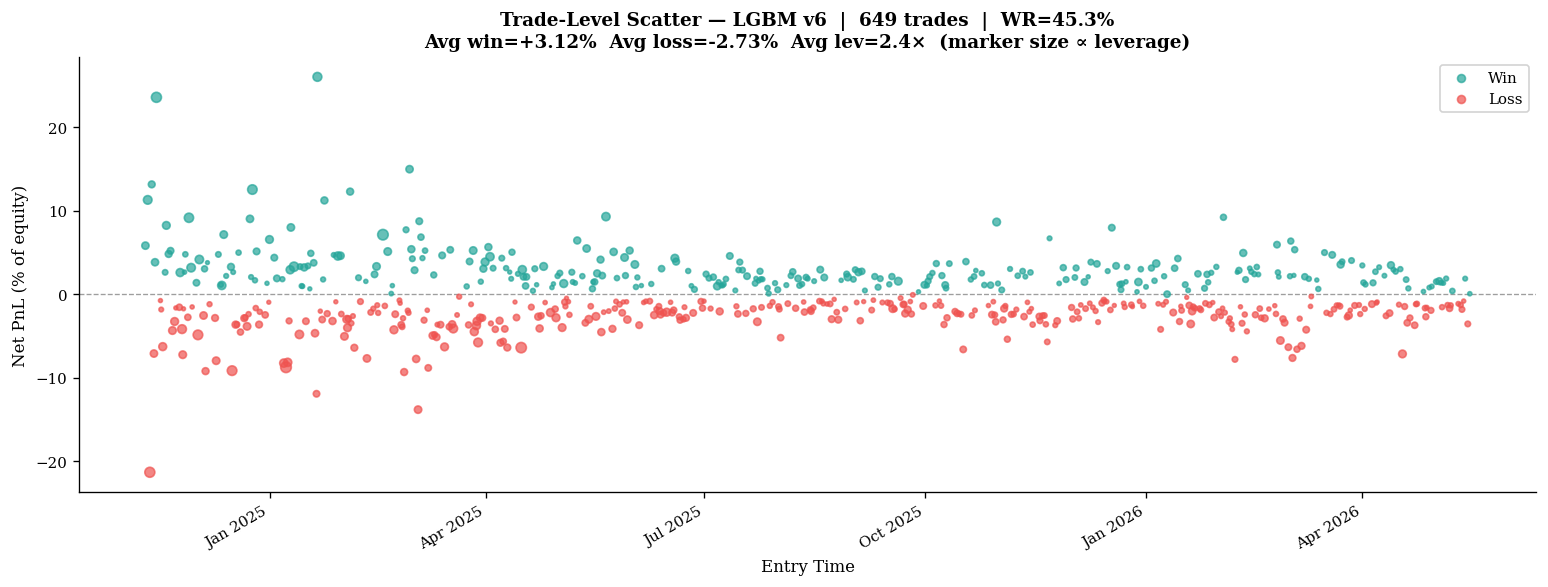

In [24]:
# ── Chart 5: Trade-level scatter (PnL over time, sized by leverage) ──────────
if len(tdf_055) > 0:
    wins  = tdf_055[tdf_055['pnl_pct'] >  0]
    loses = tdf_055[tdf_055['pnl_pct'] <= 0]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.scatter(wins['entry_time'],  wins['pnl_pct'],
               color=GREEN, alpha=0.70, s=wins['leverage'] * 5, label='Win', zorder=3)
    ax.scatter(loses['entry_time'], loses['pnl_pct'],
               color=RED,   alpha=0.70, s=loses['leverage'] * 5, label='Loss', zorder=3)
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    wr       = (tdf_055['pnl_pct'] > 0).mean()
    avg_win  = wins['pnl_pct'].mean()  if len(wins)  > 0 else 0.0
    avg_loss = loses['pnl_pct'].mean() if len(loses) > 0 else 0.0
    ax.set_xlabel('Entry Time')
    ax.set_ylabel('Net PnL (% of equity)')
    ax.set_title(
        f'Trade-Level Scatter — LGBM v6  |  {len(tdf_055)} trades  |  WR={wr:.1%}\n'
        f'Avg win={avg_win:+.2f}%  Avg loss={avg_loss:+.2f}%  '
        f'Avg lev={tdf_055["leverage"].mean():.1f}×  '
        f'(marker size ∝ leverage)',
        fontweight='bold',
    )
    ax.legend()
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '05_trade_scatter.png')
    plt.show()


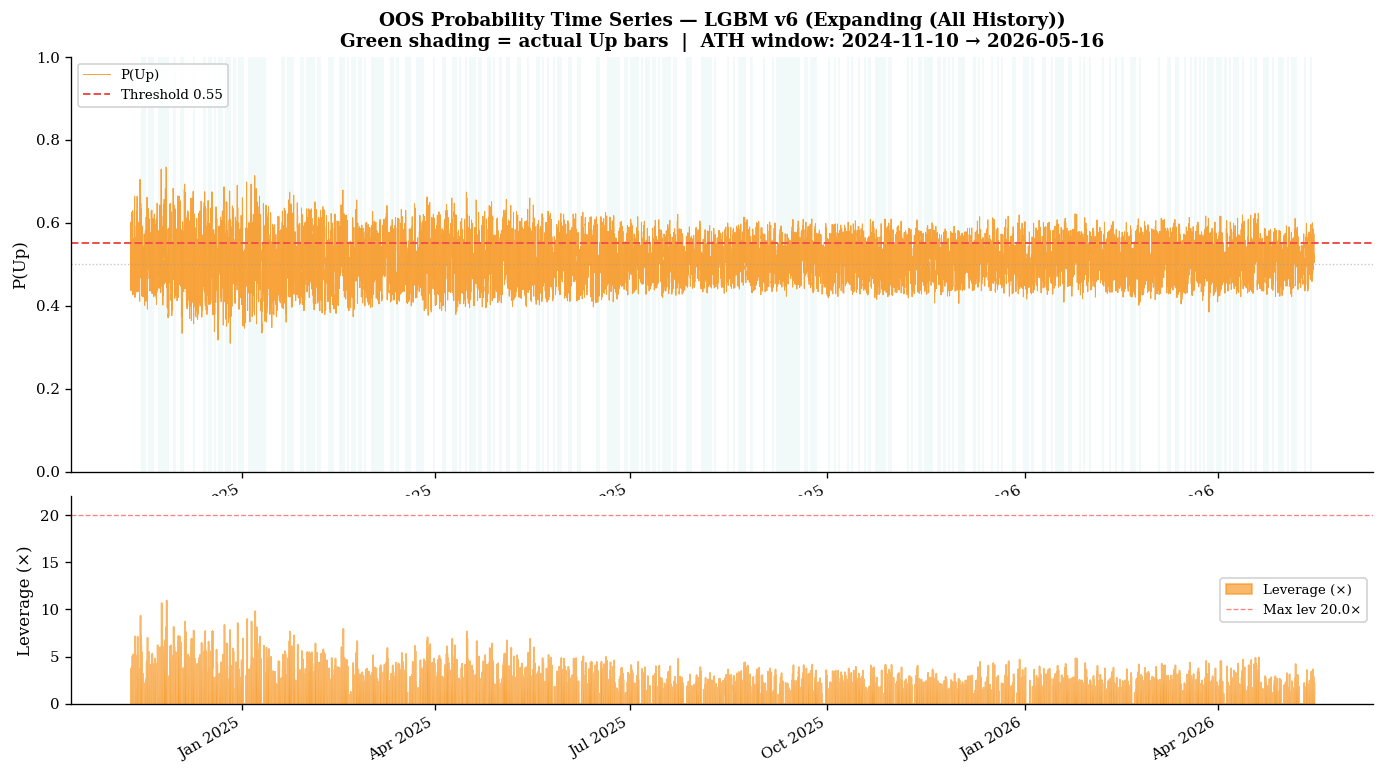

In [25]:
# ── Chart 6: OOS probability time series with leverage overlay ───────────────
pa    = best_probs_v6.values
valid = ~np.isnan(pa)

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

ax = axes[0]
chunk = 24
for i in range(0, len(oos_v6_index) - chunk, chunk):
    if y_v6[i] == 1:
        ax.axvspan(oos_v6_index[i], oos_v6_index[min(i + chunk, len(oos_v6_index) - 1)],
                   alpha=0.06, color=GREEN, linewidth=0)
ax.plot(oos_v6_index[valid], pa[valid], color=ACCENT, lw=0.6, alpha=0.85, label='P(Up)')
ax.axhline(DEFAULT_THRESHOLD, color=RED, lw=1.2, ls='--',
           label=f'Threshold {DEFAULT_THRESHOLD}')
ax.axhline(0.5, color=GREY, lw=0.8, ls=':', alpha=0.6)
ax.set_ylabel('P(Up)'); ax.set_ylim(0, 1)
ax.set_title(
    f'OOS Probability Time Series — LGBM v6 ({WFO_SCHEMES[BEST_SCHEME]["name"]})\n'
    f'Green shading = actual Up bars  |  ATH window: '
    f'{oos_v6.index.min().date()} → {oos_v6.index.max().date()}',
    fontweight='bold',
)
ax.legend(fontsize=8)

# Leverage over time (for signal bars only)
ax2 = axes[1]
lev_arr = np.array([prob_to_leverage(p, DEFAULT_THRESHOLD) if (not np.isnan(p) and p > DEFAULT_THRESHOLD) else 0
                    for p in pa])
ax2.fill_between(oos_v6_index, lev_arr, 0, color=ACCENT, alpha=0.65, label='Leverage (×)')
ax2.axhline(DEFAULT_MAX_LEV, color=RED, lw=0.8, ls='--', alpha=0.7,
            label=f'Max lev {DEFAULT_MAX_LEV}×')
ax2.set_ylabel('Leverage (×)'); ax2.set_ylim(0, DEFAULT_MAX_LEV * 1.1)
ax2.legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(ARTS_DIR / '06_prob_leverage_timeseries.png')
plt.show()


---
## Phase 6 — Leverage Sensitivity Analysis

Sweep max-leverage cap from 1× (no leverage) through 5×, 10×, 20×.
All runs use futures fees, safety cap ON, ATH window, threshold 0.55.

| Max Leverage | Interpretation |
|-------------|----------------|
| 1× | Baseline — fully unleveraged (spot-like) |
| 5× | Conservative leverage |
| 10× | Moderate leverage |
| 20× | Aggressive (default) |


In [26]:
print('=' * 65)
print('PHASE 6 — LEVERAGE SENSITIVITY ANALYSIS')
print('=' * 65)

LEV_CAPS    = [1, 5, 10, 20]
LEV_COLORS  = [GREY, BLUE, GREEN, ACCENT]
lev_results = {}

for max_lev in LEV_CAPS:
    eq_, tdf_ = run_leveraged_backtest(
        oos_v6, best_probs_v6,
        threshold=DEFAULT_THRESHOLD,
        max_lev=max_lev,
    )
    wr = (tdf_['pnl_pct'] > 0).mean() if len(tdf_) > 0 else 0.0
    lev_results[max_lev] = {
        'equity': eq_, 'trades': tdf_,
        'return': float(eq_[-1] - 1),
        'sharpe': float(_sharpe(eq_)),
        'maxdd':  float(_maxdd(eq_)),
        'win_rate': float(wr),
        'n_trades': len(tdf_),
        'avg_lev': float(tdf_['leverage'].mean()) if len(tdf_) > 0 else 0.0,
    }

print(f'{"MaxLev":>8}  {"Trades":>7}  {"AvgLev":>7}  {"WinRate":>8}  {"Return":>9}  {"Sharpe":>7}  {"MaxDD":>8}')
print('─' * 70)
for ml, m in lev_results.items():
    print(f'{ml:>7}×  {m["n_trades"]:>7}  {m["avg_lev"]:>7.1f}×  '
          f'{m["win_rate"]:>8.1%}  {m["return"]:>+8.1%}  '
          f'{m["sharpe"]:>7.3f}  {m["maxdd"]:>8.2%}')
print(f'  B&H:          {bh_v6[-1]-1:>+9.1%}  {_sharpe(bh_v6):>7.3f}  {_maxdd(bh_v6):>8.2%}')


PHASE 6 — LEVERAGE SENSITIVITY ANALYSIS
  MaxLev   Trades   AvgLev   WinRate     Return   Sharpe     MaxDD
──────────────────────────────────────────────────────────────────────
      1×      649      1.0×     45.3%    -28.5%   -0.803   -43.62%
      5×      649      1.3×     45.3%    -35.3%   -0.776   -53.11%
     10×      649      1.7×     45.3%    -44.5%   -0.779   -63.26%
     20×      649      2.4×     45.3%    -63.0%   -0.850   -78.47%
  B&H:              -0.0%   -0.000   -50.08%


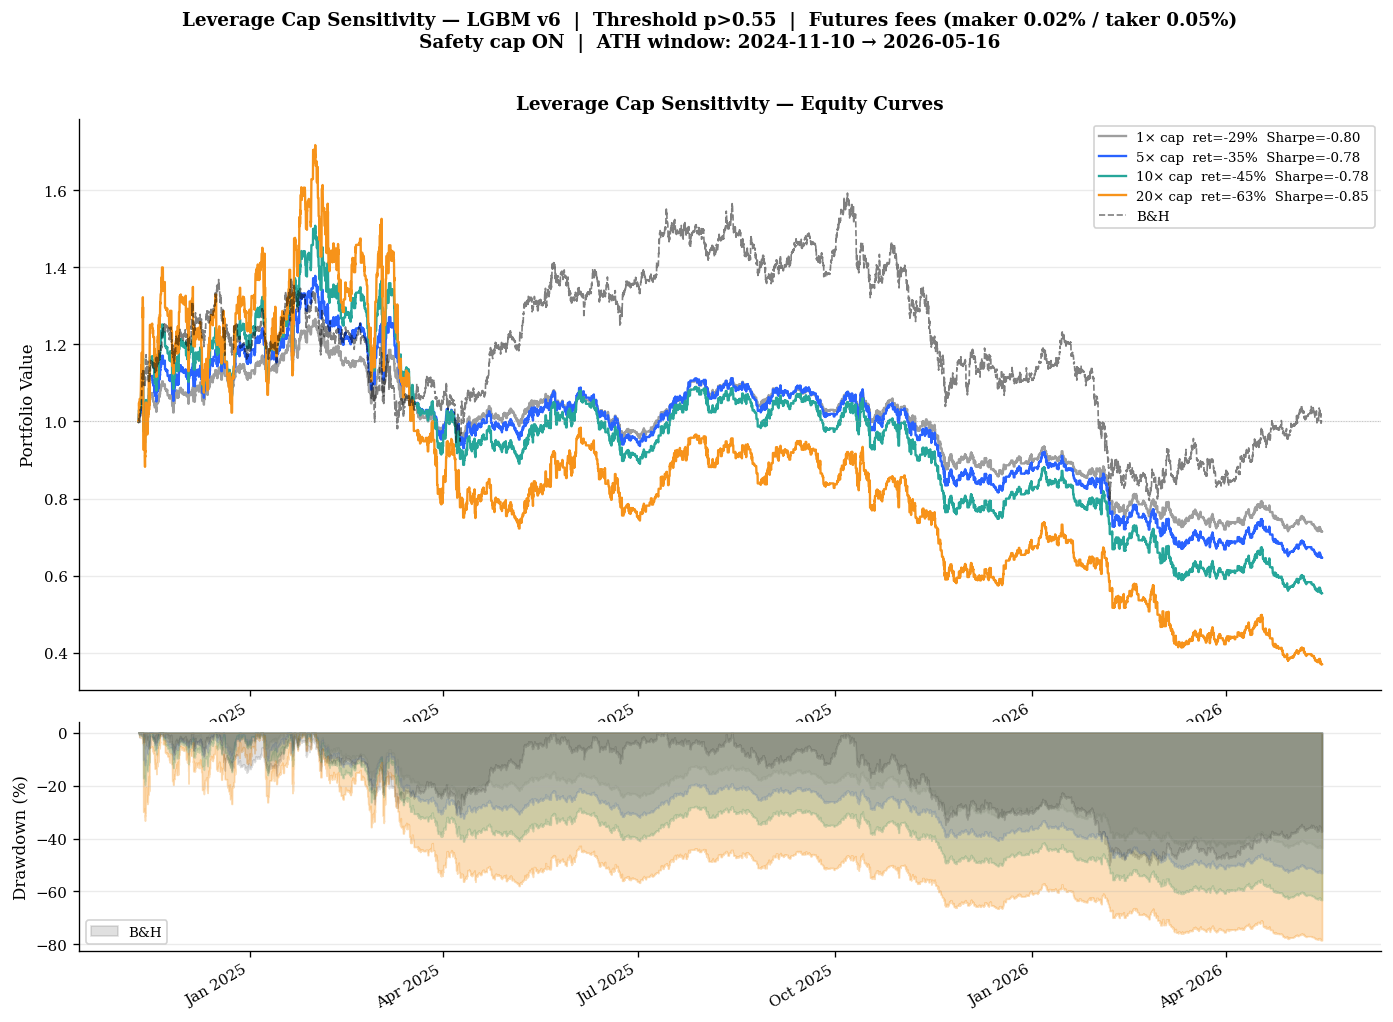

In [27]:
# ── Chart: Equity curves for each leverage cap ───────────────────────────────
fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(14, 9),
                                    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

for max_lev, color in zip(LEV_CAPS, LEV_COLORS):
    m   = lev_results[max_lev]
    eq_ = m['equity']
    lbl = f'{max_lev}× cap  ret={m["return"]:+.0%}  Sharpe={m["sharpe"]:.2f}'
    ax_eq.plot(oos_v6_index, eq_, color=color, lw=1.4, label=lbl)
    pk_ = np.maximum.accumulate(eq_)
    ax_dd.fill_between(oos_v6_index, (eq_ - pk_) / (pk_ + 1e-12) * 100, 0,
                       color=color, alpha=0.30)

ax_eq.plot(oos_v6_index, bh_v6, color='black', lw=1.0, ls='--', alpha=0.5, label='B&H')
ax_eq.axhline(1.0, color=GREY, lw=0.6, ls=':', alpha=0.5)
ax_eq.set_ylabel('Portfolio Value'); ax_eq.legend(fontsize=8); ax_eq.grid(axis='y', alpha=0.25)
ax_eq.set_title('Leverage Cap Sensitivity — Equity Curves', fontweight='bold')

pk_bh = np.maximum.accumulate(bh_v6)
ax_dd.fill_between(oos_v6_index, (bh_v6 - pk_bh) / (pk_bh + 1e-12) * 100, 0,
                   color='black', alpha=0.12, label='B&H')
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.legend(fontsize=8)
ax_dd.grid(axis='y', alpha=0.25)

for ax in (ax_eq, ax_dd):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'Leverage Cap Sensitivity — LGBM v6  |  Threshold p>{DEFAULT_THRESHOLD}  |  '
    f'Futures fees (maker {FUTURES_MAKER_FEE*100:.2f}% / taker {FUTURES_TAKER_FEE*100:.2f}%)\n'
    f'Safety cap ON  |  ATH window: {oos_v6.index.min().date()} → {oos_v6.index.max().date()}',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '07_leverage_sensitivity.png')
plt.show()


Threshold × Leverage sweep:
 threshold  max_lev  n_trades  return  sharpe  win_rate   maxdd
    0.5200        1       721 -0.0674 -0.1553    0.4521 -0.3425
    0.5200       10       721 -0.1598 -0.1986    0.4521 -0.5933
    0.5200       20       721 -0.3802 -0.3439    0.4521 -0.7969
    0.5400        1       680 -0.2643 -0.7143    0.4500 -0.4166
    0.5400       10       680 -0.4411 -0.7214    0.4500 -0.6486
    0.5400       20       680 -0.6454 -0.8203    0.4500 -0.8161
    0.5500        1       649 -0.2853 -0.8034    0.4530 -0.4362
    0.5500       10       649 -0.4454 -0.7789    0.4530 -0.6326
    0.5500       20       649 -0.6297 -0.8505    0.4530 -0.7847
    0.5600        1       611 -0.2087 -0.5823    0.4599 -0.4068
    0.5600       10       611 -0.3484 -0.6192    0.4599 -0.5781
    0.5600       20       611 -0.5226 -0.7036    0.4599 -0.7213
    0.5800        1       438 -0.2468 -0.8518    0.4452 -0.4064
    0.5800       10       438 -0.2077 -0.4176    0.4452 -0.4981
    0.5800  

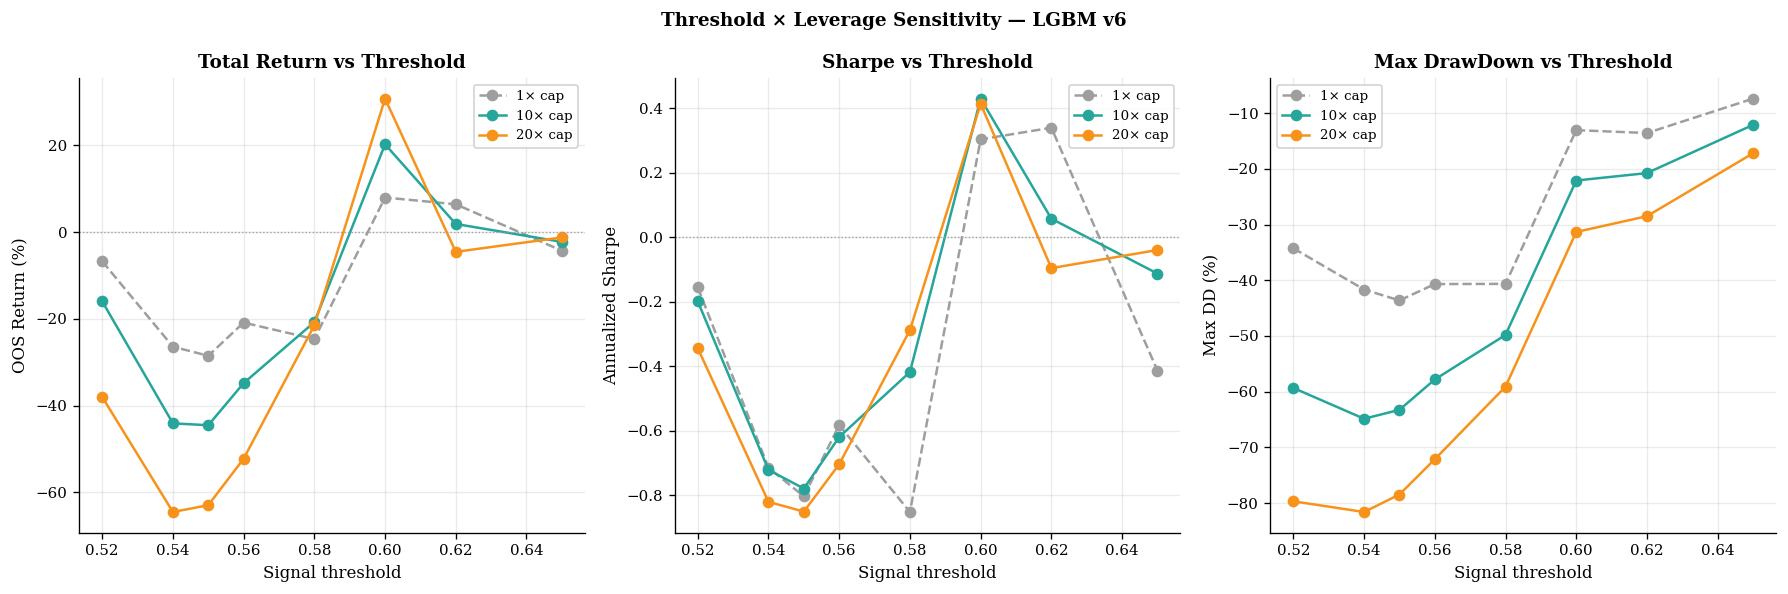

In [28]:
# ── Threshold sensitivity at 20× cap ─────────────────────────────────────────
thresholds = [0.52, 0.54, 0.55, 0.56, 0.58, 0.60, 0.62, 0.65]
sweep_rows = []

for thr in thresholds:
    for ml in [1, 10, 20]:
        eq_, tdf_ = run_leveraged_backtest(
            oos_v6, best_probs_v6, threshold=thr, max_lev=ml,
        )
        wr = (tdf_['pnl_pct'] > 0).mean() if len(tdf_) > 0 else 0.0
        sweep_rows.append({
            'threshold': thr, 'max_lev': ml,
            'n_trades':  len(tdf_),
            'return':    float(eq_[-1] - 1),
            'sharpe':    float(_sharpe(eq_)),
            'win_rate':  float(wr),
            'maxdd':     float(_maxdd(eq_)),
        })

sweep_df = pd.DataFrame(sweep_rows)
print('Threshold × Leverage sweep:')
print(sweep_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
lev_style = {1: ('--', GREY), 10: ('-', GREEN), 20: ('-', ACCENT)}

for ml, (ls, color) in lev_style.items():
    sub = sweep_df[sweep_df['max_lev'] == ml]
    axes[0].plot(sub['threshold'], sub['return']  * 100, marker='o', ls=ls,
                 color=color, lw=1.5, label=f'{ml}× cap')
    axes[1].plot(sub['threshold'], sub['sharpe'],         marker='o', ls=ls,
                 color=color, lw=1.5, label=f'{ml}× cap')
    axes[2].plot(sub['threshold'], sub['maxdd']   * 100,  marker='o', ls=ls,
                 color=color, lw=1.5, label=f'{ml}× cap')

axes[0].set_title('Total Return vs Threshold', fontweight='bold')
axes[0].set_ylabel('OOS Return (%)'); axes[0].axhline(0, color=GREY, lw=0.8, ls=':')
axes[1].set_title('Sharpe vs Threshold',       fontweight='bold')
axes[1].set_ylabel('Annualized Sharpe');        axes[1].axhline(0, color=GREY, lw=0.8, ls=':')
axes[2].set_title('Max DrawDown vs Threshold', fontweight='bold')
axes[2].set_ylabel('Max DD (%)')
for ax in axes:
    ax.set_xlabel('Signal threshold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(
    'Threshold × Leverage Sensitivity — LGBM v6',
    fontweight='bold', fontsize=11,
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '08_threshold_lev_sweep.png')
plt.show()


In [29]:
# ── Save wfo_summary.csv ─────────────────────────────────────────────────────
wfo_rows = []
for sk, m in wfo_metrics.items():
    wfo_rows.append({
        'scheme_id':   sk,
        'scheme_name': WFO_SCHEMES[sk]['name'],
        'auc':         round(m['auc'], 5),
        'sharpe':      round(m['sharpe'], 4),
        'total_ret':   round(m['total_ret'], 4),
        'maxdd':       round(m['maxdd'], 4),
        'n_signals':   m['n_signals'],
    })
wfo_summary_df = pd.DataFrame(wfo_rows)
csv_path = ARTS_DIR / 'wfo_summary.csv'
wfo_summary_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_dict_lev(eq, tdf, threshold, max_lev):
    wr = float((tdf['pnl_pct'] > 0).mean()) if len(tdf) > 0 else 0.0
    return {
        'threshold': threshold, 'max_lev': max_lev,
        'n_trades':  len(tdf),
        'win_rate':  wr,
        'total_ret': float(eq[-1] - 1),
        'sharpe':    float(_sharpe(eq)),
        'maxdd':     float(_maxdd(eq)),
        'avg_lev':   float(tdf['leverage'].mean()) if len(tdf) > 0 else 0.0,
    }

results_dict = {
    'notebook':  '02_lgbm_omni_0fee_v6',
    'version':   'v6',
    'created':   pd.Timestamp.now().isoformat(),
    'ath_start': str(ATH_START.date()),
    'ath_price': float(_end_price),
    'v6_window': {
        'start': str(oos_v6.index.min().date()),
        'end':   str(oos_v6.index.max().date()),
        'bars':  n_v6,
    },
    'fee_model': {
        'futures_maker_fee': FUTURES_MAKER_FEE,
        'futures_taker_fee': FUTURES_TAKER_FEE,
        'note': 'fees applied on notional = equity * leverage',
    },
    'leverage_model': {
        'min_lev': DEFAULT_MIN_LEV,
        'max_lev': DEFAULT_MAX_LEV,
        'prob_high': LEV_PROB_HIGH,
        'safety_cap': True,
        'max_loss_frac': LEV_MAX_LOSS_FRAC,
    },
    'feature_selection': {
        'stage0_pool':      len(ALL_FEATURE_COLS),
        'stage4_prune':     len(SELECTED_FEATURES),
    },
    'selected_features': SELECTED_FEATURES,
    'best_scheme':  BEST_SCHEME,
    'best_params':  {k: (int(v) if isinstance(v, (np.integer, int)) else float(v))
                     for k, v in BEST_PARAMS.items()},
    'backtest_lev_055': _bt_dict_lev(eq_055, tdf_055, 0.55, DEFAULT_MAX_LEV),
    'backtest_lev_060': _bt_dict_lev(eq_060, tdf_060, 0.60, DEFAULT_MAX_LEV),
    'leverage_sensitivity': {
        str(ml): {k: v for k, v in m.items() if k not in ('equity', 'trades')}
        for ml, m in lev_results.items()
    },
}
json_path = ARTS_DIR / 'results.json'
with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2, default=str)
print(f'Saved: {json_path}')

print(f'\nAll artifacts in {ARTS_DIR}:')
for p in sorted(ARTS_DIR.iterdir()):
    print(f'  {p.name:<52}  {p.stat().st_size / 1024:>6.1f} KB')


Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v6/wfo_summary.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v6/results.json

All artifacts in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v6:
  00_pipeline_funnel.png                                 124.1 KB
  01_equity_drawdown.png                                 978.5 KB
  01_wfo_scheme_comparison.png                           738.9 KB
  02_grid_search_heatmap.png                             204.3 KB
  02_leverage_analysis.png                               385.3 KB
  03_prob_distributions.png                              125.9 KB
  04_feature_importance.png                              167.6 KB
  05_trade_scatter.png                                   487.8 KB
  06_prob_leverage_timeseries.png                        444.5 KB
  07_leverage_sensitivity.png                     

---
## Results Summary

### v6 Changes vs v5

| Feature | v5 | v6 |
|---------|----|----||
| Backtest window | Fixed OOS start (2024-01-01) | ATH-anchored (when BTC first hit end-price) |
| Position sizing | 100% equity, 1× | Conviction-weighted 1×–20× leverage |
| Fee model | Spot (longs free, SL/timeout 0.05%) | Futures (longs: 0.02% maker / 0.05% taker × leverage) |
| Fee on long entry | 0% | 0.02% × leverage |
| Phase 6 | Fee impact analysis | Leverage sensitivity sweep |

### Leverage Model

```
prob ≤ 0.55  →  no trade
prob = 0.55  →  1× leverage
prob = 0.72  →  ~10× leverage
prob ≥ 0.90  →  20× leverage (capped)
```

Safety cap prevents SL from wiping >90% of equity: `max_lev = 0.90 / (1.5 × ATR_pct)`.
